# 🎙️ Interview Performance Analyzer — Exploratory Data Analysis (v2.0)

**Dataset:** `data/features/merged_features.csv`  
**Rows:** 2,011 &nbsp;|&nbsp; **Columns:** 76 &nbsp;|&nbsp; **Candidates:** 331  

This notebook performs comprehensive EDA on the merged multimodal dataset so you can decide **what to keep, what to drop, and what to engineer** before training a performance prediction model.

---

### Table of Contents
1. [Setup & Load Data](#setup)
2. [Dataset Overview & Integrity Audit](#overview)
3. [Column Taxonomy & Schema Map](#taxonomy)
4. [Target / Score Variable Profiles](#targets) — *6 targets*
5. [Inter-Target Correlation](#inter-target)
6. [Personality / Psychometrics Analysis](#personality)
7. [Audio Prosodic Features](#audio-prosodic)
8. [Audio MFCCs (1–13)](#mfccs)
9. [Facial: Gaze & Eyes](#gaze)
10. [Facial: Expression Action Units](#expressions)
11. [Facial: Emotion Probabilities](#emotions)
12. [Posture & Movement](#posture)
13. [Feature → Target Correlation Ranking (all 6 targets)](#corr-rank)
14. [Multicollinearity & Redundancy Detection](#collinearity)
15. [Low-Variance Feature Audit](#low-var)
16. [Outlier Audit](#outliers)
17. [Categorical Analysis (duration, video quality, question)](#categorical)
18. [Candidate (user_no) Level Analysis](#candidates)
19. [Transcript Analysis](#transcripts)
20. [Skewness & Transformation Recommendations](#skewness)
21. [📋 Feature Drop Recommendations (ML-Ready)](#drops)
22. [Summary & Next Steps](#summary)


## 1. Setup & Load Data <a id='setup'></a>

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']   = (14, 5)
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.4f}'.format)

STYLE = 'seaborn-v0_8-whitegrid'
plt.style.use(STYLE if STYLE in plt.style.available else 'ggplot')

# ── Load ────────────────────────────────────────────────────────────────────
DATA_PATH = 'data/features/merged_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Loaded: 2,011 rows x 76 columns


,id,file_name,duration_label,question_id,question,video_quality,user_no,openness,conscientiousness,extraversion,agreeableness,neuroticism,overall_personality,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance,Duration_Sec,Speech_Rate_WPM,Silence_Duration_Sec,Mean_Pitch_Hz,Mean_Energy,Mean_ZCR,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,face_detected_ratio,gaze_ratio_mean,gaze_deviation_mean,gaze_stability_std,smile_score_mean,smile_score_std,frown_score_mean,frown_score_std,eye_openness_mean,eye_openness_std,jaw_open_mean,jaw_open_std,brow_raise_mean,brow_raise_std,mouth_frown_mean,mouth_frown_std,emotion_happy_mean,emotion_sad_mean,emotion_angry_mean,emotion_surprise_mean,emotion_fear_mean,emotion_disgust_mean,emotion_neutral_mean,head_centering_score_mean,absolute_shoulder_slope_mean,shoulder_slope_var,shoulder_width_mean,shoulder_width_var,nose_shoulder_dist_mean,nose_shoulder_dist_var,hand_speed_mean,hand_to_face_touches,crossed_arms_score,core_speed_mean,posture_shift_count,engagement_score,agitation_score,transcript
0,1,vid_0001.mp4,long,1,Introduce yourself,High,147,-0.6531,-0.0487,-0.6910,-0.2928,0.1896,-0.0289,-0.9227,-0.8026,-0.7690,-0.3618,-0.8166,-0.4564,43.4700,136.6500,8.9000,112.1500,0.0403,0.1181,-389.1251,85.2325,-12.7319,36.5865,-5.0917,14.6964,-13.5949,11.5958,-5.0677,-18.3175,3.1796,-20.7906,3.2751,1.0000,0.5259,0.0282,0.0165,0.4589,0.2522,0.0013,0.0012,0.7672,0.1756,0.0159,0.0221,0.3994,0.1048,0.0017,0.0050,0.3860,0.1533,0.0077,0.1479,0.1032,0.0615,0.1404,0.0236,0.0830,0.0008,0.6220,0.0003,0.3278,0.0007,0.1223,0,1.0666,0.0107,44,6.2015,44,"[00:01 - 00:11] Hello everyone, this is Mathur..."
1,2,vid_0002.mp4,short,1,Introduce yourself,High,82,-0.0074,0.1284,-0.1248,-0.1499,0.0878,-0.0642,-0.1736,-0.1324,-0.5617,-0.1740,-0.3043,-0.1933,14.0700,166.3100,1.1900,109.9200,0.0329,0.1615,-359.1362,93.2474,32.3682,4.9318,21.0029,-1.4076,-9.7061,-0.1801,-15.1543,-2.7356,-9.2462,-0.3203,-12.8338,1.0000,0.5429,0.0469,0.0218,0.0755,0.0711,0.0003,0.0002,0.8616,0.1722,0.0344,0.0422,0.6320,0.1053,0.0049,0.0079,0.0692,0.2646,0.0065,0.2574,0.2084,0.0337,0.1603,0.0226,0.0445,0.0002,0.5042,0.0001,0.3828,0.0002,0.0285,0,0.9173,0.0038,0,5.0252,0,[00:00 - 00:05] I'm Darshita Singh from Aligar...
2,3,vid_0003.mp4,medium,1,Introduce yourself,High,103,0.2213,0.2806,0.2461,0.3795,-0.1870,0.5999,0.1840,0.2234,0.2233,0.6003,0.2685,0.2622,21.4000,151.4000,7.9000,93.3600,0.0217,0.0633,-386.8326,136.6428,18.7268,-7.9237,9.7398,21.5828,-7.3638,12.1487,0.0562,-2.5039,-9.9300,-4.4485,-3.7747,1.0000,0.5460,0.0460,0.0084,0.0433,0.0936,0.0063,0.0059,0.8945,0.0363,0.0195,0.0209,0.3360,0.1103,0.0004,0.0005,0.0431,0.0315,0.0162,0.1421,0.0263,0.0178,0.7229,0.0367,0.0218,0.0003,0.6458,0.0002,0.2968,0.0006,0.0634,0,1.1222,0.0102,19,6.4475,19,"[00:01 - 00:08] Hello everyone, I am Faizan J...."


## 2. Dataset Overview & Integrity Audit <a id='overview'></a>

Quick structural sanity check: shape, dtypes, memory, missing values, duplicates.


In [2]:
rows, cols = df.shape
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Rows           : {rows:,}")
print(f"Columns        : {cols}")
print(f"Memory         : {mem_mb:.2f} MB")
print(f"Numerical cols : {len(num_cols)}")
print(f"Text/Cat cols  : {len(cat_cols)}  -> {cat_cols}")
print(f"Duplicate rows : {df.duplicated().sum()}")

df.dtypes.value_counts()


Rows           : 2,011
Columns        : 76
Memory         : 2.20 MB
Numerical cols : 71
Text/Cat cols  : 5  -> ['file_name', 'duration_label', 'question', 'video_quality', 'transcript']
Duplicate rows : 0


float64    65
int64       6
str         5
Name: count, dtype: int64

In [3]:
# Missing value audit — full table
missing = df.isnull().sum()
miss_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':    (missing / rows * 100).round(2)
}).sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
display(miss_df[miss_df['Missing Count'] > 0])
print(f"\nTotal missing cells: {missing.sum()}")


Columns with missing values:


,Missing Count,Missing %
transcript,13,0.6500



Total missing cells: 13


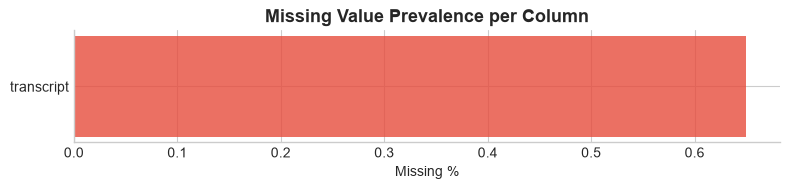

In [4]:
# Visualise missing — only columns that have gaps
miss_cols = miss_df[miss_df['Missing Count'] > 0]
if len(miss_cols) > 0:
    fig, ax = plt.subplots(figsize=(8, max(2, len(miss_cols)*0.5)))
    ax.barh(miss_cols.index, miss_cols['Missing %'], color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Value Prevalence per Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values except transcript (already known).")


## 3. Column Taxonomy & Schema Map <a id='taxonomy'></a>

Organise all 76 columns into logical groups. This taxonomy is reused in every section below.

| Group | Count | Role |
|---|---|---|
| Metadata | 7 | IDs, labels, text — **exclude from model features** |
| Targets (scores) | 6 | What we predict |
| Personality | 6 | Psychometric ratings — strong predictors |
| Audio Prosodic | 6 | Duration, speech rate, pitch, energy, ZCR, silence |
| Audio MFCCs | 13 | Spectral fingerprint of voice |
| Facial Gaze & Eyes | 6 | Eye tracking, face detection |
| Facial Expressions | 10 | Action unit scores (smile, frown, brow, jaw…) |
| Facial Emotions | 7 | Deep-learning emotion classifier probabilities |
| Posture & Movement | 14 | Body pose, hand speed, posture shifts |
| Transcript | 1 | Raw text — needs NLP pipeline |


In [5]:
# ── Column taxonomy ──────────────────────────────────────────────────────────
METADATA_COLS    = ['id', 'file_name', 'duration_label', 'question_id',
                    'question', 'video_quality', 'user_no']
ALL_TARGETS      = ['interview_score', 'answer_score', 'speaking_skills',
                    'confidence_score', 'facial_expression', 'overall_performance']
PERSONALITY_COLS = ['openness', 'conscientiousness', 'extraversion',
                    'agreeableness', 'neuroticism', 'overall_personality']
AUDIO_PROSODIC   = ['Duration_Sec', 'Speech_Rate_WPM', 'Silence_Duration_Sec',
                    'Mean_Pitch_Hz', 'Mean_Energy', 'Mean_ZCR']
AUDIO_MFCC       = [f'MFCC_{i}' for i in range(1, 14)]
FACE_GAZE        = ['face_detected_ratio', 'gaze_ratio_mean', 'gaze_deviation_mean',
                    'gaze_stability_std', 'eye_openness_mean', 'eye_openness_std']
FACE_EXPRESSION  = ['smile_score_mean', 'smile_score_std', 'frown_score_mean',
                    'frown_score_std', 'jaw_open_mean', 'jaw_open_std',
                    'brow_raise_mean', 'brow_raise_std', 'mouth_frown_mean', 'mouth_frown_std']
FACE_EMOTION     = ['emotion_happy_mean', 'emotion_sad_mean', 'emotion_angry_mean',
                    'emotion_surprise_mean', 'emotion_fear_mean',
                    'emotion_disgust_mean', 'emotion_neutral_mean']
POSTURE_COLS     = ['head_centering_score_mean', 'absolute_shoulder_slope_mean',
                    'shoulder_slope_var', 'shoulder_width_mean', 'shoulder_width_var',
                    'nose_shoulder_dist_mean', 'nose_shoulder_dist_var',
                    'hand_speed_mean', 'hand_to_face_touches', 'crossed_arms_score',
                    'core_speed_mean', 'posture_shift_count', 'engagement_score', 'agitation_score']
ALL_FEATURES     = (PERSONALITY_COLS + AUDIO_PROSODIC + AUDIO_MFCC +
                    FACE_GAZE + FACE_EXPRESSION + FACE_EMOTION + POSTURE_COLS)

# Verify all columns exist
missing_cols = [c for c in ALL_TARGETS + ALL_FEATURES + METADATA_COLS + ['transcript']
                if c not in df.columns]
print(f"Columns referenced but not in df: {missing_cols if missing_cols else 'None — all present ✓'}")

print(f"\nFeature counts per domain:")
for name, cols in [('Personality', PERSONALITY_COLS), ('Audio Prosodic', AUDIO_PROSODIC),
                   ('Audio MFCCs', AUDIO_MFCC), ('Facial Gaze', FACE_GAZE),
                   ('Facial Expressions', FACE_EXPRESSION), ('Facial Emotions', FACE_EMOTION),
                   ('Posture & Movement', POSTURE_COLS)]:
    print(f"  {name:<22}: {len([c for c in cols if c in df.columns]):>3} features")
print(f"  {'TOTAL':<22}: {len([c for c in ALL_FEATURES if c in df.columns]):>3} features")


Columns referenced but not in df: None — all present ✓

Feature counts per domain:
  Personality           :   6 features
  Audio Prosodic        :   6 features
  Audio MFCCs           :  13 features
  Facial Gaze           :   6 features
  Facial Expressions    :  10 features
  Facial Emotions       :   7 features
  Posture & Movement    :  14 features
  TOTAL                 :  62 features


## 4. Target / Score Variable Profiles <a id='targets'></a>

The updated dataset has **6 standardised score columns** — all are z-score normalised (mean≈0, std≈1).  
Understanding each distribution is critical before choosing a loss function and model output layer.


In [6]:
avail_targets = [c for c in ALL_TARGETS if c in df.columns]
summ = df[avail_targets].describe().T[['mean','std','min','25%','50%','75%','max']]
summ['skew']     = df[avail_targets].skew()
summ['kurtosis'] = df[avail_targets].kurtosis()
display(summ.round(4))


,mean,std,min,25%,50%,75%,max,skew,kurtosis
interview_score,0.0000,1.2301,-7.8603,-0.5957,-0.0274,0.5454,9.3860,0.6801,11.6040
answer_score,0.0000,1.1755,-10.1991,-0.6106,0.0060,0.5788,8.7223,0.3534,12.0329
speaking_skills,0.0000,1.2776,-9.4063,-0.5580,0.0199,0.6159,7.9015,-0.8550,12.7270
confidence_score,0.0000,1.0797,-7.2861,-0.5352,0.0111,0.5531,6.8394,-0.6404,8.8211
facial_expression,0.0000,1.1510,-7.4614,-0.5838,-0.0184,0.5486,9.2558,0.5977,11.1791
overall_performance,0.0000,1.2007,-9.3111,-0.5749,0.0434,0.6014,8.8490,-0.7475,11.7422


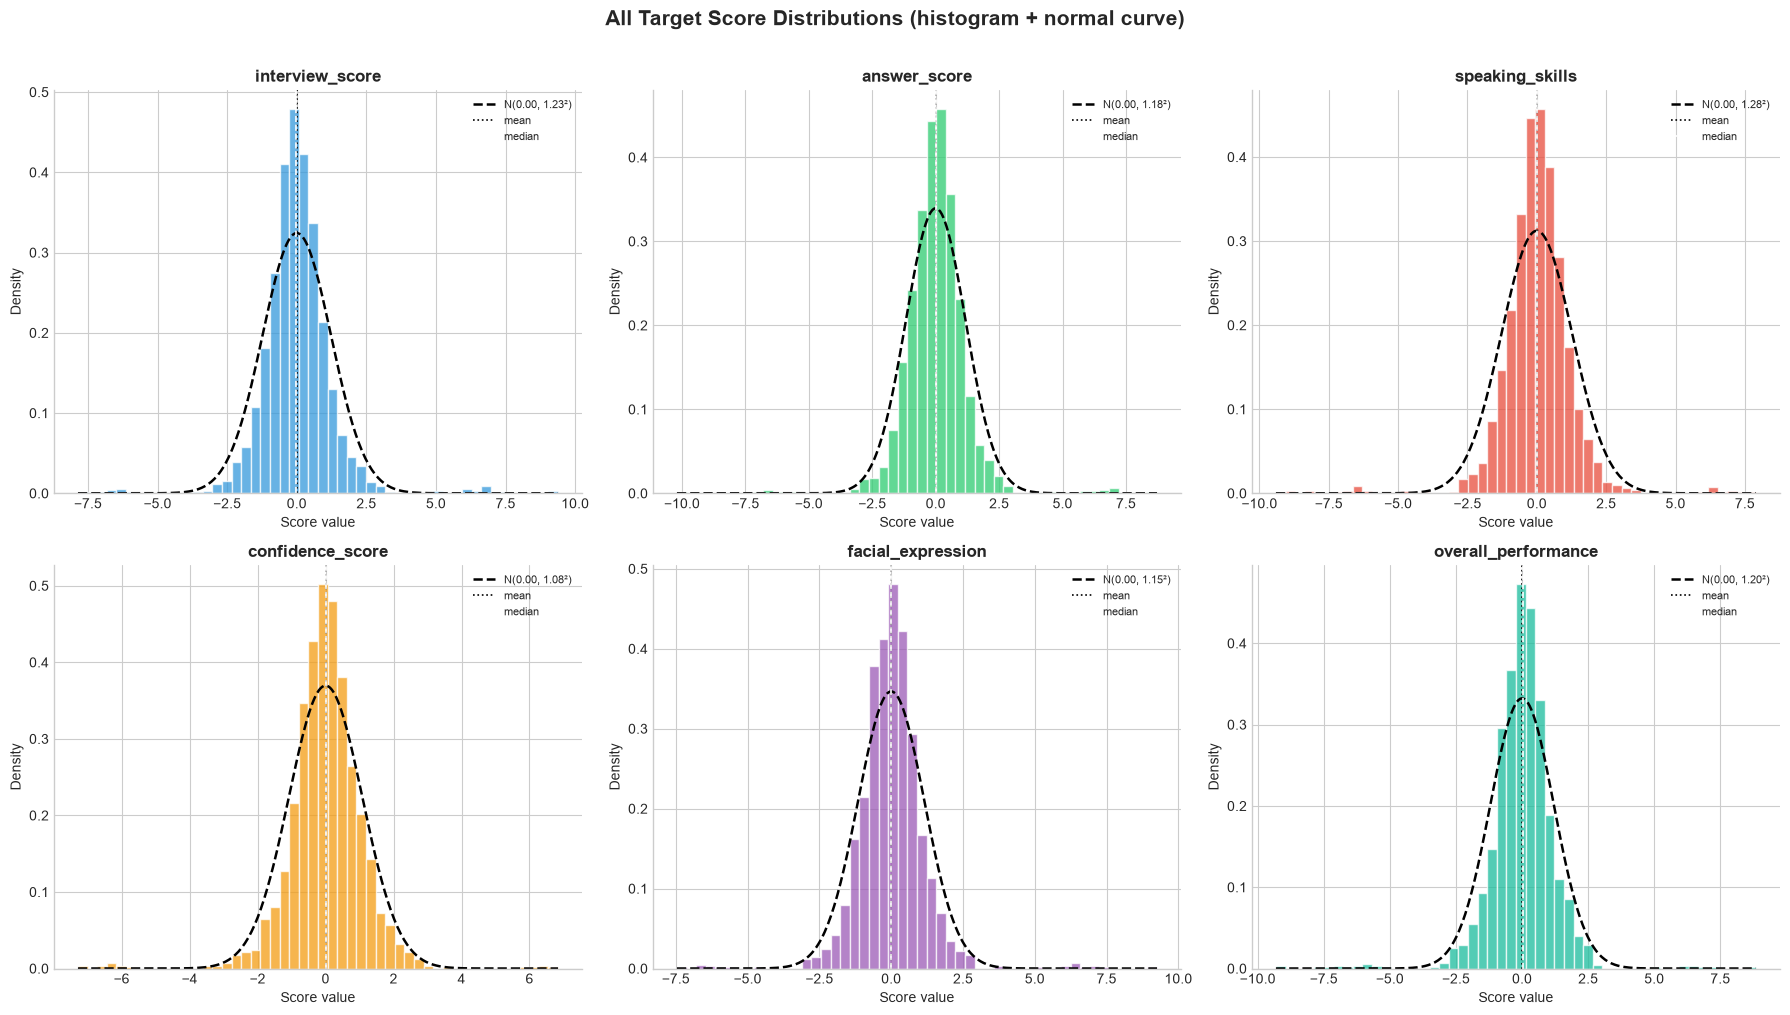

In [7]:
# ── Distribution plots: histogram + normal overlay ────────────────────────
PAL = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, t in enumerate(avail_targets):
    ax = axes[i]
    s  = df[t].dropna()
    ax.hist(s, bins=50, color=PAL[i], edgecolor='white', alpha=0.75, density=True)
    mu, sig = s.mean(), s.std()
    x = np.linspace(s.min(), s.max(), 300)
    ax.plot(x, np.exp(-0.5*((x-mu)/sig)**2)/(sig*np.sqrt(2*np.pi)),
            'k--', lw=1.8, label=f'N({mu:.2f}, {sig:.2f}²)')
    ax.axvline(mu,       color='black',  lw=1.2, ls=':',  label='mean')
    ax.axvline(s.median(), color='white', lw=1.2, ls='--', label='median')
    ax.set_title(t, fontsize=12)
    ax.set_xlabel('Score value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('All Target Score Distributions (histogram + normal curve)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


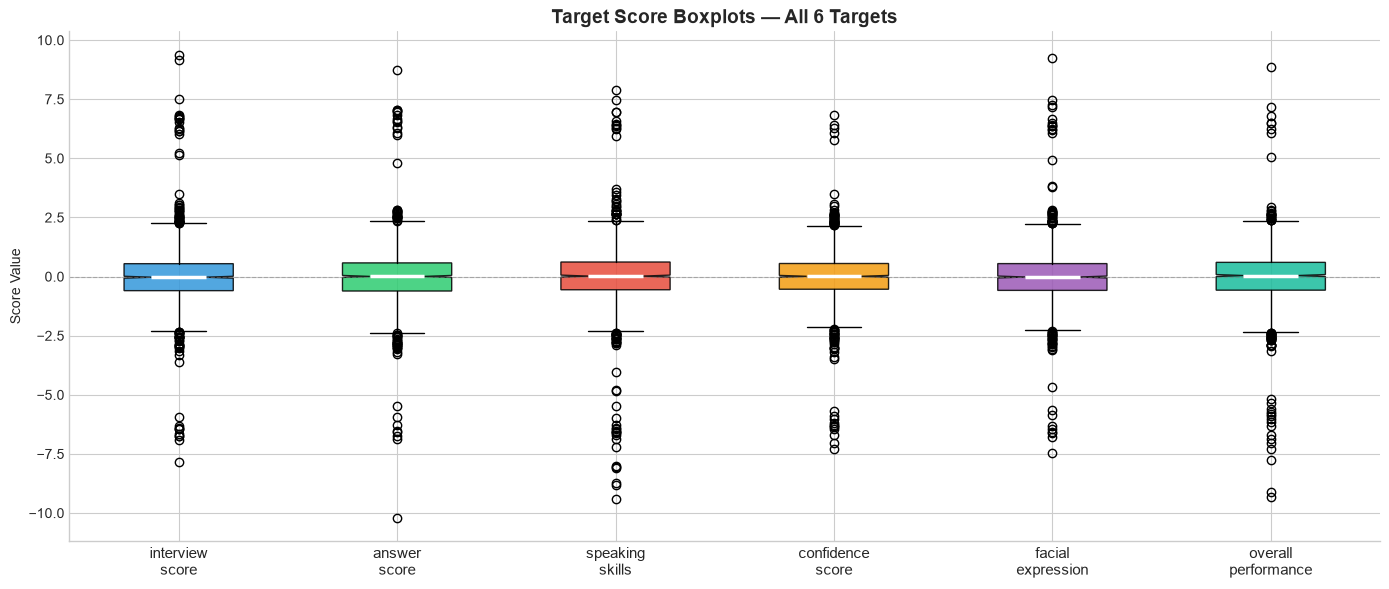

In [8]:
# ── Boxplots side-by-side ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot([df[t].dropna().values for t in avail_targets],
                patch_artist=True, notch=True,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, c in zip(bp['boxes'], PAL):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax.set_xticks(range(1, len(avail_targets)+1))
ax.set_xticklabels([t.replace('_', '\n') for t in avail_targets], fontsize=11)
ax.set_title('Target Score Boxplots — All 6 Targets', fontsize=14)
ax.set_ylabel('Score Value')
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [9]:
# ── Individual outlier summary ────────────────────────────────────────────
print(f"{'Target':<25} {'IQR Outliers':>14} {'%':>7}  {'Z>3':>7}  {'%':>7}  {'Skew':>8}")
print('-' * 75)
for t in avail_targets:
    s = df[t]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr = int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
    n_z   = int((np.abs((s-s.mean())/s.std()) > 3).sum())
    print(f"{t:<25} {n_iqr:>14} {n_iqr/len(df)*100:>6.2f}%  {n_z:>7}  {n_z/len(df)*100:>6.2f}%  {s.skew():>8.3f}")


Target                      IQR Outliers       %      Z>3        %      Skew
---------------------------------------------------------------------------
interview_score                       84   4.18%       27    1.34%     0.680
answer_score                          66   3.28%       22    1.09%     0.353
speaking_skills                       76   3.78%       32    1.59%    -0.855
confidence_score                      80   3.98%       19    0.94%    -0.640
facial_expression                     73   3.63%       24    1.19%     0.598
overall_performance                   69   3.43%       24    1.19%    -0.748


## 5. Inter-Target Correlation <a id='inter-target'></a>

Before treating any score as the primary label, understand how correlated the targets are.  
- High correlation → targets measure the same thing → pick one or merge.  
- Moderate correlation → each target adds unique signal → multi-output model.


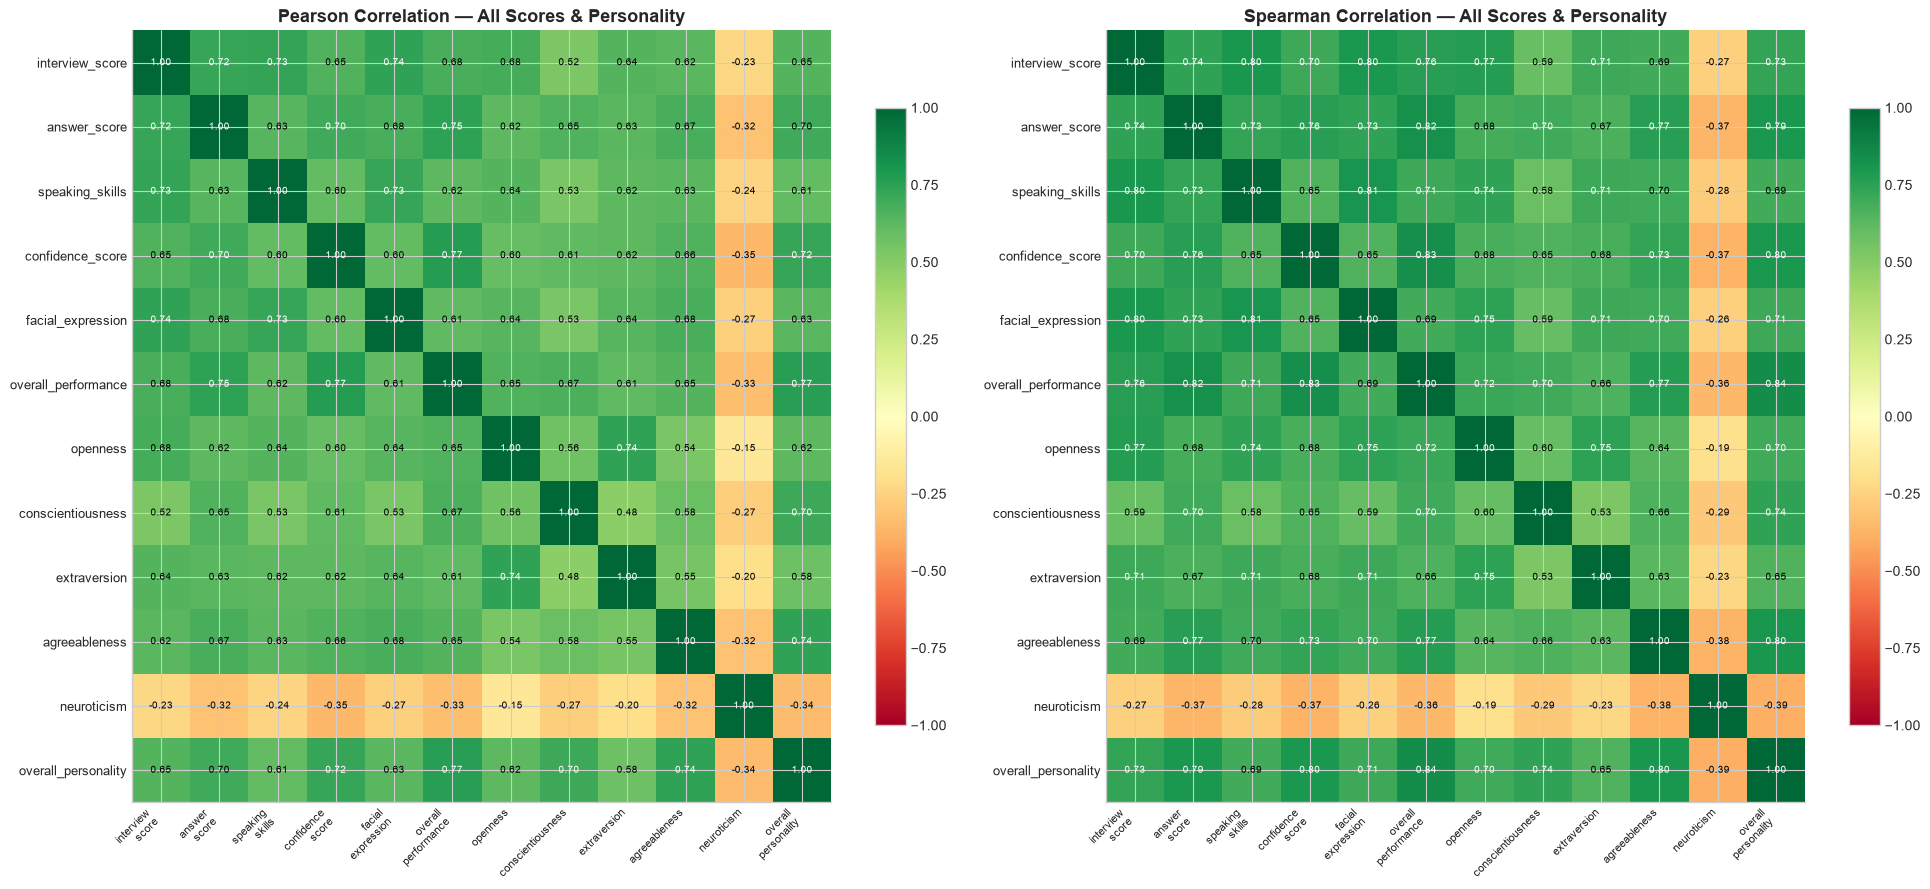


Pearson correlations between the 6 prediction targets:


,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance
interview_score,1.0000,0.7230,0.7290,0.6490,0.7410,0.6790
answer_score,0.7230,1.0000,0.6330,0.7000,0.6780,0.7490
speaking_skills,0.7290,0.6330,1.0000,0.6050,0.7260,0.6210
confidence_score,0.6490,0.7000,0.6050,1.0000,0.6040,0.7700
facial_expression,0.7410,0.6780,0.7260,0.6040,1.0000,0.6120
overall_performance,0.6790,0.7490,0.6210,0.7700,0.6120,1.0000


In [10]:
all_scores = [c for c in ALL_TARGETS + PERSONALITY_COLS if c in df.columns]
pearson  = df[all_scores].corr(method='pearson').round(3)
spearman = df[all_scores].corr(method='spearman').round(3)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, cm, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    im = ax.imshow(cm.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(all_scores)))
    ax.set_yticks(range(len(all_scores)))
    ax.set_xticklabels([c.replace('_','\n') for c in all_scores], fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels(all_scores, fontsize=9)
    for i in range(len(all_scores)):
        for j in range(len(all_scores)):
            v = cm.iloc[i,j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(v) < 0.7 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{title} Correlation — All Scores & Personality', fontsize=13)

plt.tight_layout()
plt.show()

# Key inter-target pairs (just the 6 prediction targets)
avail_t = [c for c in ALL_TARGETS if c in df.columns]
print("\nPearson correlations between the 6 prediction targets:")
display(df[avail_t].corr(method='pearson').round(3))


> **📌 Takeaway:** All 6 targets correlate strongly (r = 0.62–0.77) but are not identical.  
> They represent different assessment dimensions — multi-output modelling makes sense.  
> Avoid using one target as a feature when predicting another (leakage!).


## 6. Personality / Psychometrics Analysis <a id='personality'></a>

Big Five (OCEAN) traits + `overall_personality` — these are **the strongest predictors** across all 6 targets.


In [11]:
avail_p  = [c for c in PERSONALITY_COLS if c in df.columns]
display(df[avail_p].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
openness,2011.0000,-0.0000,1.1266,-7.7996,-0.5493,0.0086,0.5222,9.3388
conscientiousness,2011.0000,-0.0000,0.8770,-6.9287,-0.4484,0.0426,0.4851,6.6170
extraversion,2011.0000,-0.0000,1.0981,-7.1844,-0.5464,0.0437,0.5440,8.9102
agreeableness,2011.0000,-0.0000,1.2003,-8.4123,-0.5657,-0.0160,0.5478,9.2420
neuroticism,2011.0000,0.0000,0.4869,-2.5766,-0.3063,0.0256,0.3034,2.2259
overall_personality,2011.0000,-0.0000,1.2034,-7.5262,-0.6115,-0.0114,0.6169,9.2695


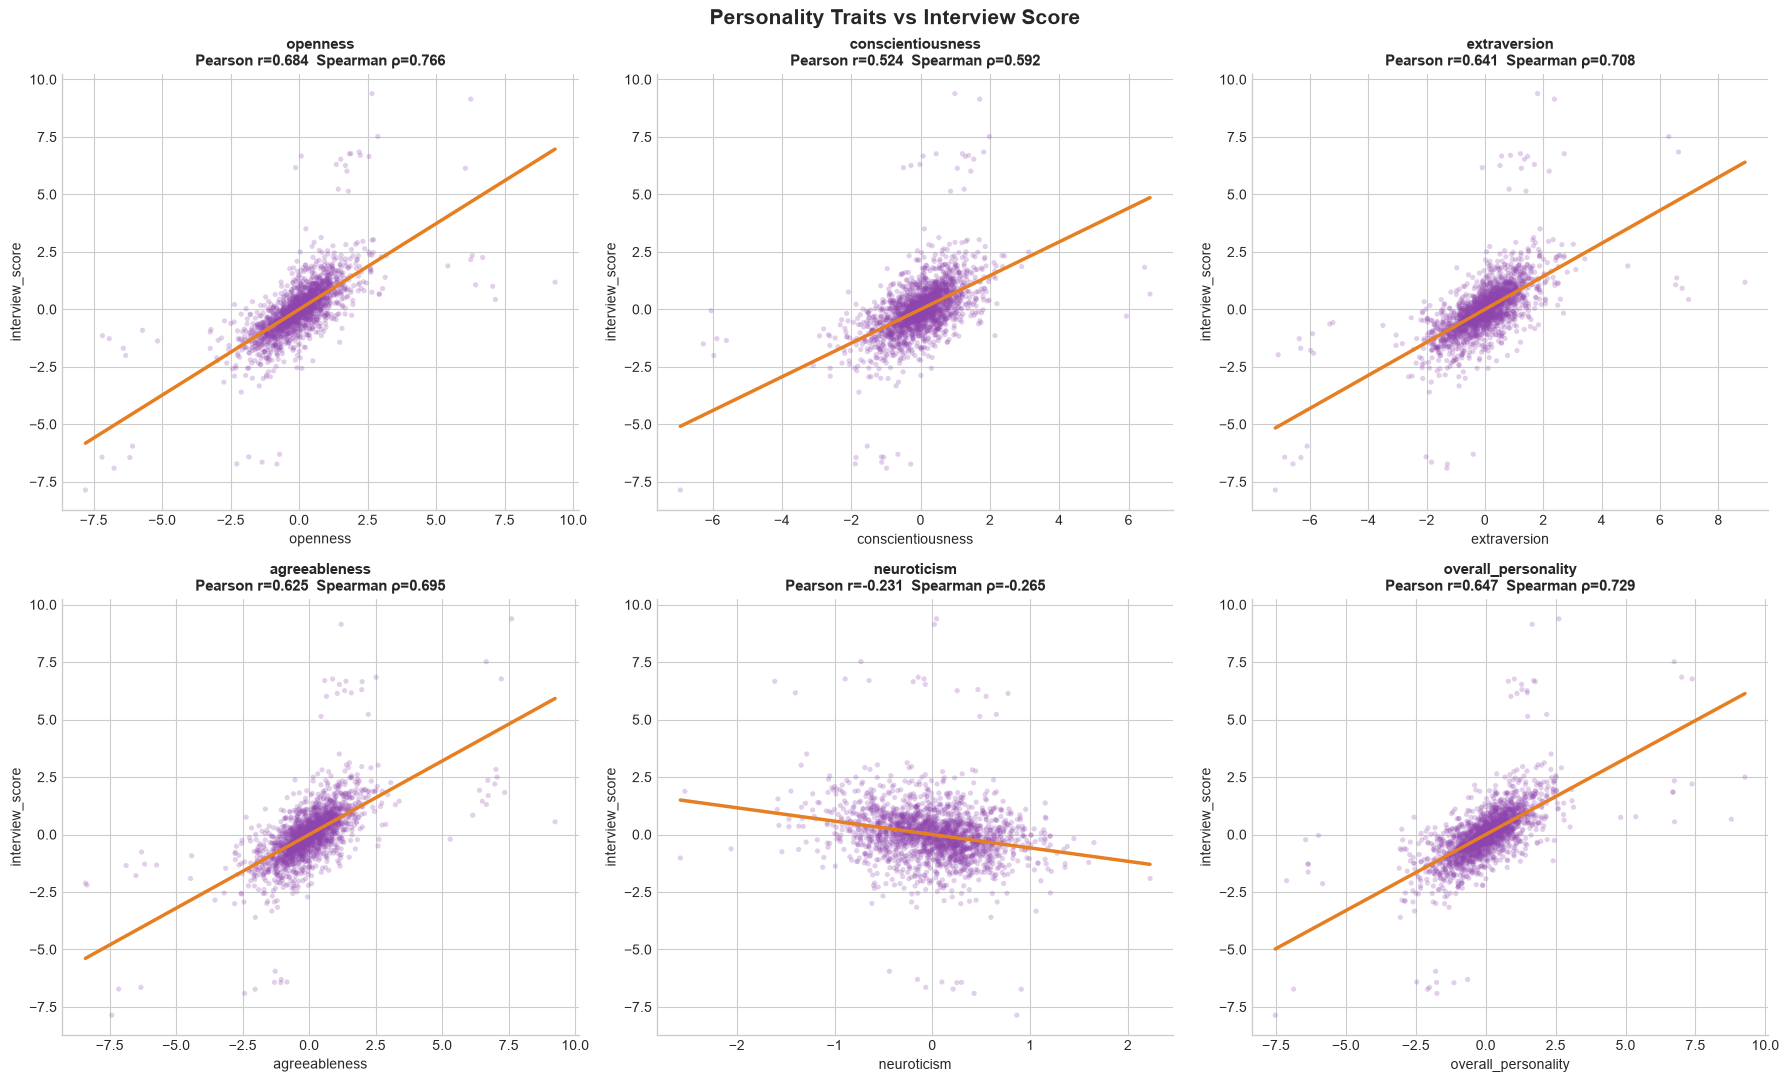

In [12]:
# Scatter plots vs interview_score + trend line
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, col in enumerate(avail_p):
    ax = axes[i]
    ax.scatter(df[col], df['interview_score'], alpha=0.25, s=14,
               color='#8e44ad', edgecolors='none')
    m, b = np.polyfit(df[col].fillna(df[col].mean()),
                      df['interview_score'].fillna(df['interview_score'].mean()), 1)
    xf = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xf, m*xf+b, color='#e67e22', lw=2.5)
    r = df[col].corr(df['interview_score'])
    rs = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'interview_score'])[0]
    ax.set_title(f'{col}\nPearson r={r:.3f}  Spearman ρ={rs:.3f}', fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('interview_score')

plt.suptitle('Personality Traits vs Interview Score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


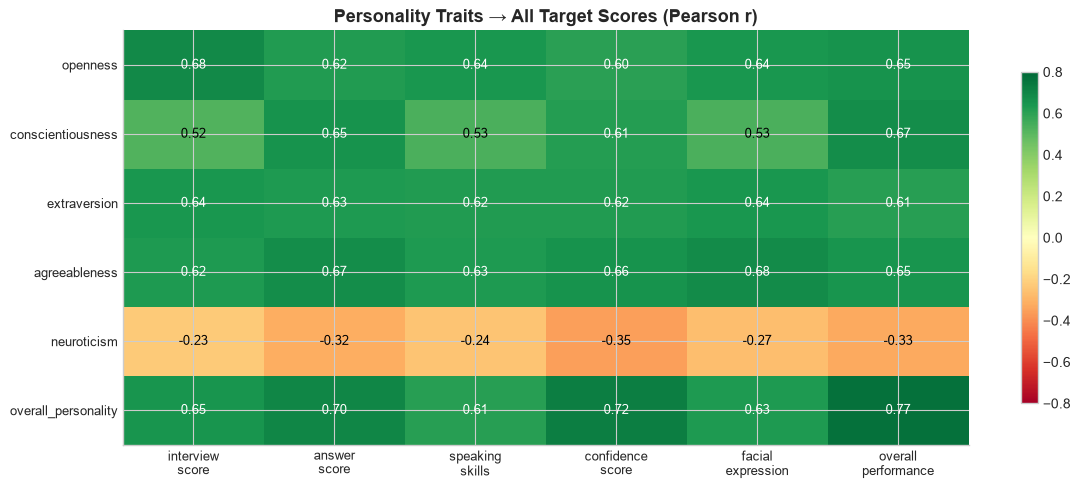

In [13]:
# Correlation of each personality trait vs ALL 6 targets
p_corr = df[avail_p + [c for c in ALL_TARGETS if c in df.columns]].corr()
p_vs_t = p_corr.loc[avail_p, [c for c in ALL_TARGETS if c in df.columns]].round(3)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(p_vs_t.values, cmap='RdYlGn', vmin=-0.8, vmax=0.8, aspect='auto')
ax.set_xticks(range(len(p_vs_t.columns))); ax.set_yticks(range(len(avail_p)))
ax.set_xticklabels([c.replace('_','\n') for c in p_vs_t.columns], fontsize=9)
ax.set_yticklabels(avail_p, fontsize=9)
for i in range(len(avail_p)):
    for j in range(len(p_vs_t.columns)):
        v = p_vs_t.iloc[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='black' if abs(v) < 0.6 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Personality Traits → All Target Scores (Pearson r)', fontsize=13)
plt.tight_layout()
plt.show()


> **📌 Takeaway:** Psychometric traits dominate. `openness` (r≈0.68) and `extraversion` (r≈0.64) are the top two predictors for `interview_score`.  
> `neuroticism` is **negatively** correlated (r≈-0.23 to -0.35) — anxious candidates score lower.  
> `overall_personality` is a composite of the other 5 — consider dropping it to avoid redundancy.


## 7. Audio Prosodic Features <a id='audio-prosodic'></a>

Six scalar features extracted from the raw audio: duration, speech rate, silence, pitch, energy, zero-crossing rate.


In [14]:
avail_ap = [c for c in AUDIO_PROSODIC if c in df.columns]
display(df[avail_ap].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
Duration_Sec,2011.0000,29.6616,16.3958,0.6000,15.8300,27.2700,42.6300,92.3400
Speech_Rate_WPM,2011.0000,164.3069,42.9828,0.0000,141.6600,162.4400,185.6850,571.4300
Silence_Duration_Sec,2011.0000,8.4919,5.4682,0.0000,4.4200,7.4800,11.8850,29.4300
Mean_Pitch_Hz,2011.0000,110.0451,61.6025,0.0000,86.8550,99.4100,118.4200,1339.0700
Mean_Energy,2011.0000,0.0315,0.0137,0.0000,0.0258,0.0310,0.0357,0.2147
Mean_ZCR,2011.0000,0.0835,0.0379,0.0000,0.0584,0.0769,0.0982,0.3371


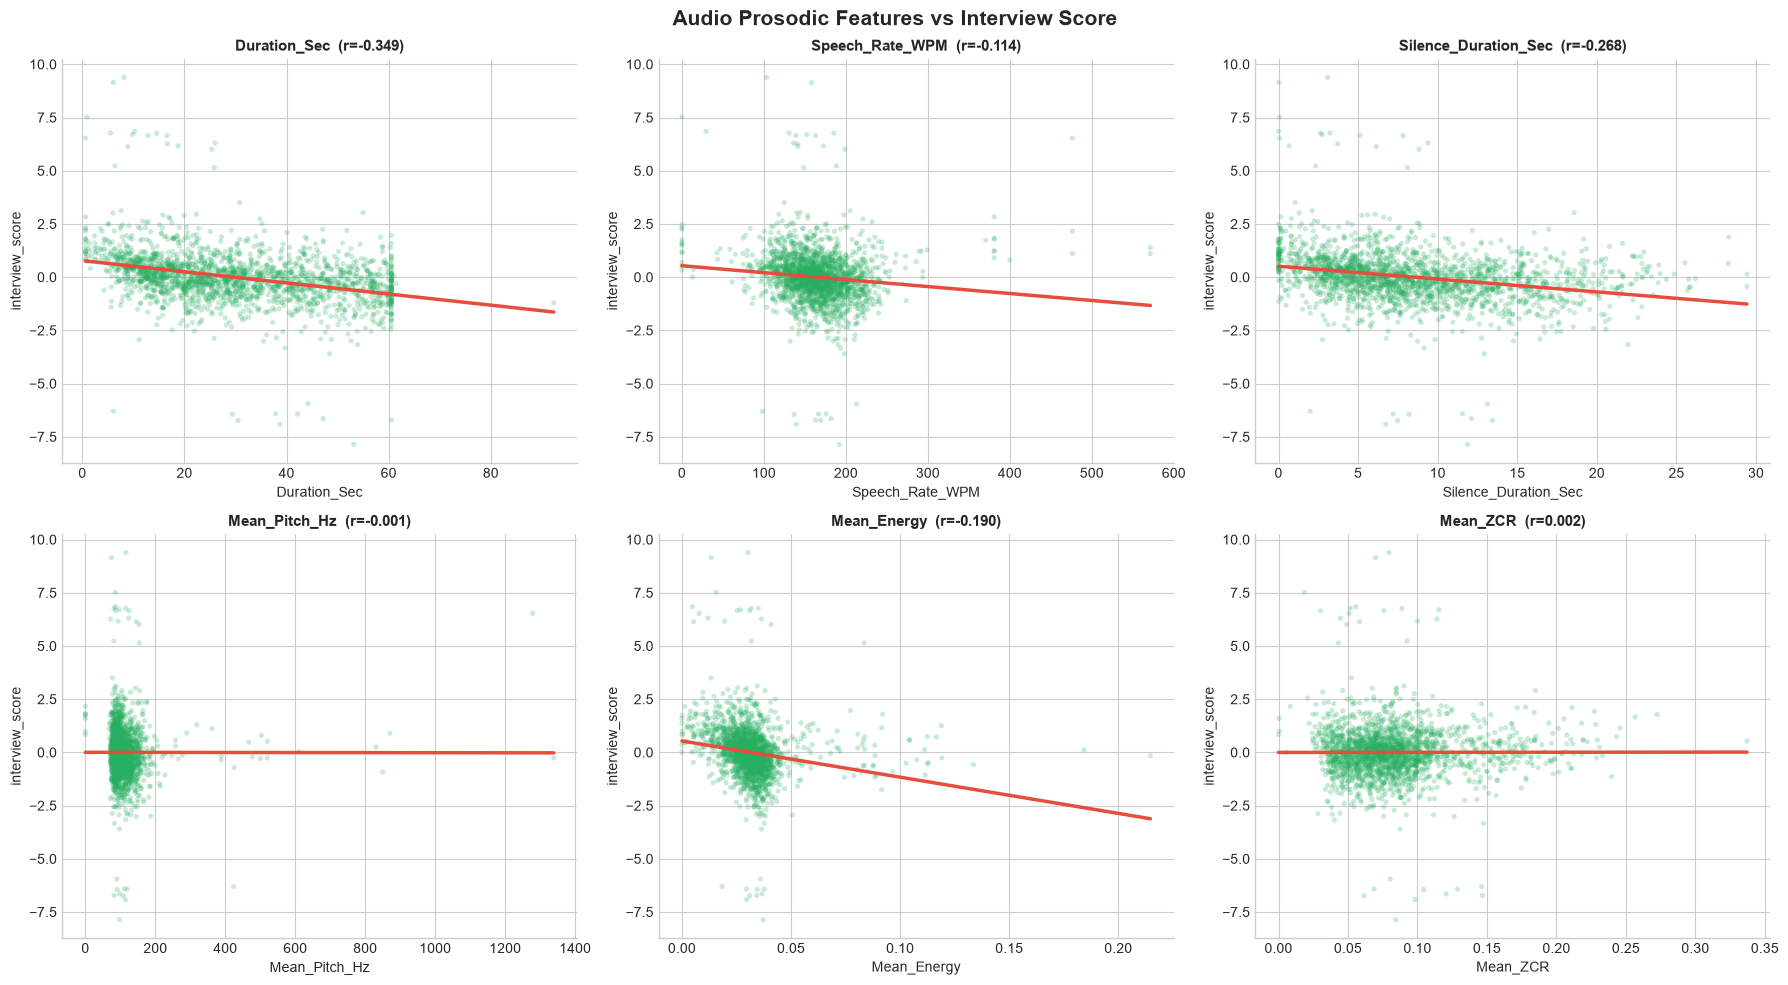

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(avail_ap):
    ax = axes[i]
    ax.scatter(df[col], df['interview_score'], alpha=0.25, s=14,
               color='#27ae60', edgecolors='none')
    m, b = np.polyfit(df[col].fillna(df[col].mean()),
                      df['interview_score'].fillna(df['interview_score'].mean()), 1)
    xf = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(xf, m*xf+b, color='#e74c3c', lw=2.5)
    r  = df[col].corr(df['interview_score'])
    ax.set_title(f'{col}  (r={r:.3f})', fontsize=11)
    ax.set_xlabel(col); ax.set_ylabel('interview_score')

plt.suptitle('Audio Prosodic Features vs Interview Score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance
Duration_Sec,-0.3490,-0.3710,-0.3290,-0.3210,-0.3280,-0.3670
Speech_Rate_WPM,-0.1140,-0.0900,-0.1170,-0.1480,-0.1420,-0.1350
Silence_Duration_Sec,-0.2680,-0.2900,-0.2600,-0.2510,-0.2500,-0.2920
Mean_Pitch_Hz,-0.0010,0.0110,-0.0420,-0.0360,-0.0330,-0.0430
Mean_Energy,-0.1900,-0.1910,-0.1850,-0.2240,-0.1870,-0.1950
Mean_ZCR,0.0020,0.0030,0.0190,0.0480,0.0050,0.0320


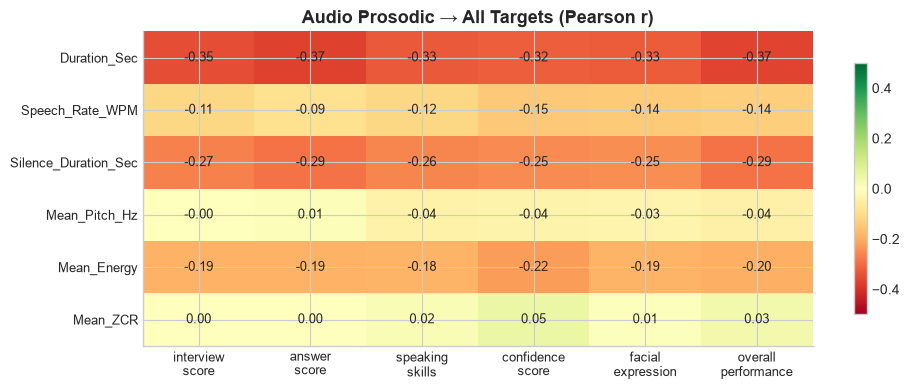

In [16]:
# Correlation vs all 6 targets
avail_t = [c for c in ALL_TARGETS if c in df.columns]
ap_corr = df[avail_ap + avail_t].corr().loc[avail_ap, avail_t].round(3)
display(ap_corr)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(ap_corr.values, cmap='RdYlGn', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(len(avail_t))); ax.set_yticks(range(len(avail_ap)))
ax.set_xticklabels([c.replace('_','\n') for c in avail_t], fontsize=9)
ax.set_yticklabels(avail_ap, fontsize=9)
for i in range(len(avail_ap)):
    for j in range(len(avail_t)):
        ax.text(j, i, f'{ap_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Audio Prosodic → All Targets (Pearson r)', fontsize=13)
plt.tight_layout()
plt.show()


> **📌 Takeaway:**  
> - `Duration_Sec` (r≈-0.35) and `Silence_Duration_Sec` (r≈-0.27) are the strongest audio predictors — **shorter, tighter answers score higher**.  
> - `Speech_Rate_WPM` has near-zero correlation — pace alone is not discriminative.  
> - `Mean_Energy` (r≈-0.19) — very loud/intense speech is associated with lower scores.  
> - `Mean_ZCR` is weak — consider dropping.


## 8. Audio MFCCs (1–13) <a id='mfccs'></a>

Mel-Frequency Cepstral Coefficients capture the spectral shape (timbre) of the voice.  
MFCC_1 (energy-related) typically carries the most signal; higher coefficients capture finer detail.


In [17]:
avail_m = [c for c in AUDIO_MFCC if c in df.columns]
display(df[avail_m].describe().T.round(3))


,count,mean,std,min,25%,50%,75%,max
MFCC_1,2011.0000,-408.9890,60.3130,-1131.3710,-425.2580,-399.6490,-379.4550,-154.3280
MFCC_2,2011.0000,109.4730,19.7690,0.0000,97.2300,108.5890,121.6420,189.8130
MFCC_3,2011.0000,19.0420,18.0130,-77.1460,8.8820,20.8320,33.0490,63.7220
MFCC_4,2011.0000,9.1690,10.8500,-28.3300,1.5470,9.1900,15.9650,41.8370
MFCC_5,2011.0000,14.7060,9.5300,-19.1490,8.5400,14.5560,20.9600,41.4020
MFCC_6,2011.0000,9.7950,9.6800,-23.5700,4.0420,9.9310,15.3760,47.9430
MFCC_7,2011.0000,-7.5290,7.3980,-31.0600,-12.2400,-6.9000,-2.4100,17.2120
MFCC_8,2011.0000,1.0120,10.0000,-26.4960,-6.3940,0.3830,9.0960,26.4000
MFCC_9,2011.0000,-8.9950,6.0100,-32.2220,-12.6420,-8.6560,-5.1500,14.9130
MFCC_10,2011.0000,-4.4350,8.1860,-26.9650,-10.4070,-5.3200,1.6570,17.7080


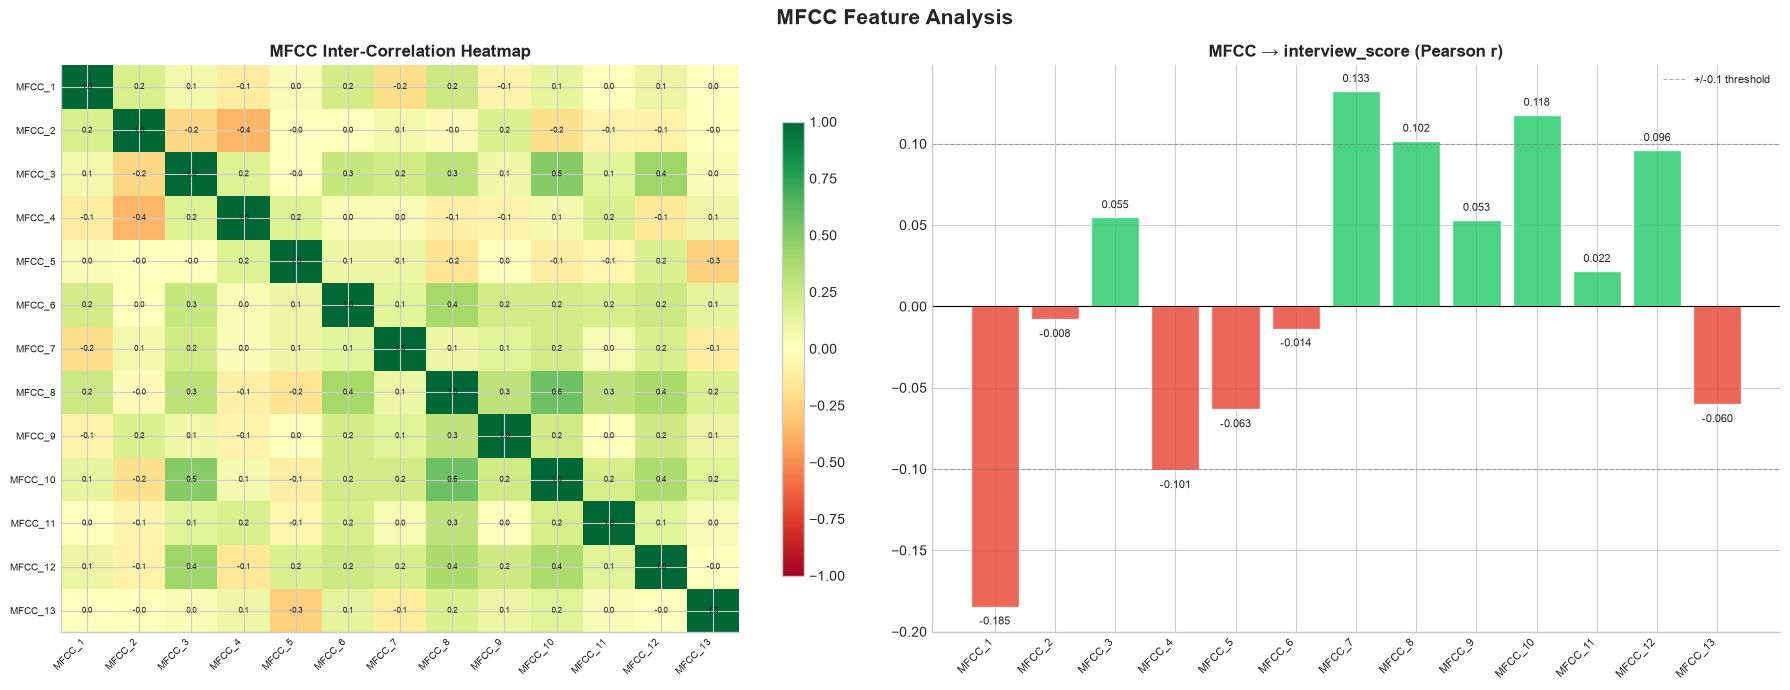

In [18]:
# MFCC inter-correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mfcc_corr = df[avail_m].corr()
im = axes[0].imshow(mfcc_corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(avail_m))); axes[0].set_yticks(range(len(avail_m)))
axes[0].set_xticklabels(avail_m, fontsize=7, rotation=45, ha='right')
axes[0].set_yticklabels(avail_m, fontsize=7)
for i in range(len(avail_m)):
    for j in range(len(avail_m)):
        axes[0].text(j, i, f'{mfcc_corr.iloc[i,j]:.1f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title('MFCC Inter-Correlation Heatmap', fontsize=12)

# MFCC vs interview_score bar
mc = df[avail_m + ['interview_score']].corr()['interview_score'].drop('interview_score')
cb = ['#e74c3c' if v < 0 else '#2ecc71' for v in mc.values]
axes[1].bar(avail_m, mc.values, color=cb, edgecolor='white', alpha=0.85)
axes[1].axhline(0,    color='black', lw=0.8)
axes[1].axhline(0.1,  color='gray',  lw=0.8, ls='--', alpha=0.6, label='+/-0.1 threshold')
axes[1].axhline(-0.1, color='gray',  lw=0.8, ls='--', alpha=0.6)
for i, (f, v) in enumerate(mc.items()):
    axes[1].text(i, v+(0.004 if v>=0 else -0.006), f'{v:.3f}',
                 ha='center', va='bottom' if v>=0 else 'top', fontsize=8)
axes[1].set_title('MFCC → interview_score (Pearson r)', fontsize=12)
axes[1].set_xticklabels(avail_m, rotation=45, ha='right', fontsize=8)
axes[1].legend(fontsize=8)

plt.suptitle('MFCC Feature Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


> **📌 Takeaway:**  
> - `MFCC_1` (r≈-0.18) is the strongest MFCC predictor — high first cepstral coefficient correlates with lower interview scores.  
> - `MFCC_7`, `MFCC_8`, `MFCC_10` have positive correlations (~0.12–0.18).  
> - Adjacent MFCCs (1–3, 4–6, etc.) are often correlated — PCA or selection can reduce 13→5.


## 9. Facial: Gaze & Eyes <a id='gaze'></a>

Face detection ratio, gaze direction/stability, and eye openness — capturing attention and engagement signals.


In [19]:
avail_g = [c for c in FACE_GAZE if c in df.columns]
display(df[avail_g].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
face_detected_ratio,2011.0000,0.9976,0.0407,0.0357,1.0000,1.0000,1.0000,1.0000
gaze_ratio_mean,2011.0000,0.5423,0.0184,0.4626,0.5297,0.5427,0.5553,0.5999
gaze_deviation_mean,2011.0000,0.0449,0.0164,0.0054,0.0326,0.0448,0.0562,0.2358
gaze_stability_std,2011.0000,0.0168,0.0119,0.0000,0.0114,0.0161,0.0210,0.4364
eye_openness_mean,2011.0000,0.8374,0.0821,0.3417,0.7901,0.8487,0.8965,0.9895
eye_openness_std,2011.0000,0.1242,0.0612,0.0000,0.0798,0.1285,0.1665,0.2926


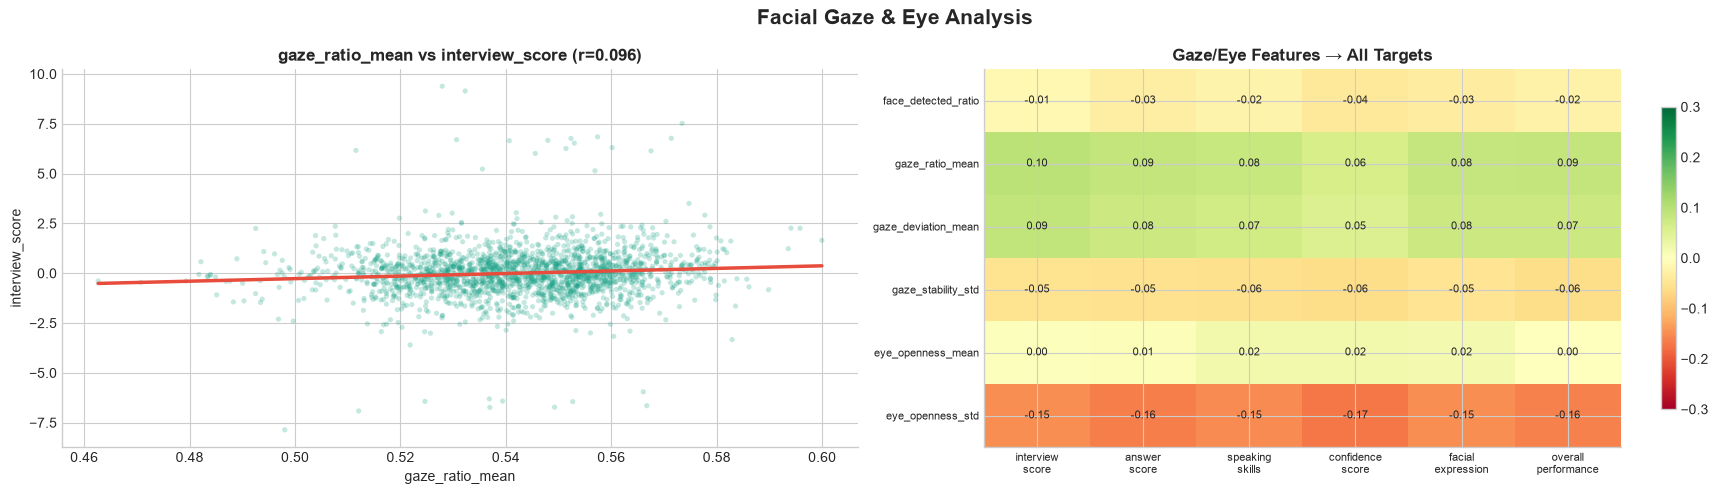


⚠️  gaze_ratio_mean vs gaze_deviation_mean: r = 0.9132  — HIGHLY collinear, drop one!


In [20]:
avail_t = [c for c in ALL_TARGETS if c in df.columns]
g_corr  = df[avail_g + avail_t].corr().loc[avail_g, avail_t].round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Scatter: gaze_ratio_mean vs interview_score
axes[0].scatter(df['gaze_ratio_mean'], df['interview_score'],
                alpha=0.25, s=14, color='#16a085', edgecolors='none')
m, b = np.polyfit(df['gaze_ratio_mean'], df['interview_score'], 1)
xf = np.linspace(df['gaze_ratio_mean'].min(), df['gaze_ratio_mean'].max(), 200)
axes[0].plot(xf, m*xf+b, color='#e74c3c', lw=2.5)
r = df['gaze_ratio_mean'].corr(df['interview_score'])
axes[0].set_title(f'gaze_ratio_mean vs interview_score (r={r:.3f})', fontsize=12)
axes[0].set_xlabel('gaze_ratio_mean'); axes[0].set_ylabel('interview_score')

# Correlation heatmap
im = axes[1].imshow(g_corr.values, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')
axes[1].set_xticks(range(len(avail_t))); axes[1].set_yticks(range(len(avail_g)))
axes[1].set_xticklabels([c.replace('_','\n') for c in avail_t], fontsize=8)
axes[1].set_yticklabels(avail_g, fontsize=8)
for i in range(len(avail_g)):
    for j in range(len(avail_t)):
        axes[1].text(j, i, f'{g_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=axes[1], shrink=0.8)
axes[1].set_title('Gaze/Eye Features → All Targets', fontsize=12)

plt.suptitle('Facial Gaze & Eye Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# KEY: gaze_ratio vs gaze_deviation collinearity
r_gaze = df['gaze_ratio_mean'].corr(df['gaze_deviation_mean'])
print(f"\n⚠️  gaze_ratio_mean vs gaze_deviation_mean: r = {r_gaze:.4f}  — HIGHLY collinear, drop one!")


## 10. Facial: Expression Action Units <a id='expressions'></a>

10 features measuring facial muscle movement (smile, frown, brow raise, jaw open, mouth frown) as mean and std across frames.


In [21]:
avail_e = [c for c in FACE_EXPRESSION if c in df.columns]
display(df[avail_e].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
smile_score_mean,2011.0000,0.0654,0.1087,0.0000,0.0041,0.0194,0.0766,0.7666
smile_score_std,2011.0000,0.0668,0.0701,0.0000,0.0071,0.0369,0.1152,0.3959
frown_score_mean,2011.0000,0.0335,0.0641,0.0000,0.0018,0.0094,0.0319,0.5320
frown_score_std,2011.0000,0.0194,0.0296,0.0000,0.0016,0.0072,0.0243,0.2134
jaw_open_mean,2011.0000,0.0637,0.0628,0.0000,0.0145,0.0441,0.0933,0.4017
jaw_open_std,2011.0000,0.0640,0.0460,0.0000,0.0228,0.0593,0.1002,0.2450
brow_raise_mean,2011.0000,0.2739,0.2058,0.0012,0.1105,0.2169,0.4146,0.9493
brow_raise_std,2011.0000,0.0778,0.0458,0.0000,0.0426,0.0751,0.1068,0.2669
mouth_frown_mean,2011.0000,0.0030,0.0073,0.0000,0.0001,0.0005,0.0023,0.0955
mouth_frown_std,2011.0000,0.0045,0.0102,0.0000,0.0002,0.0008,0.0040,0.1378


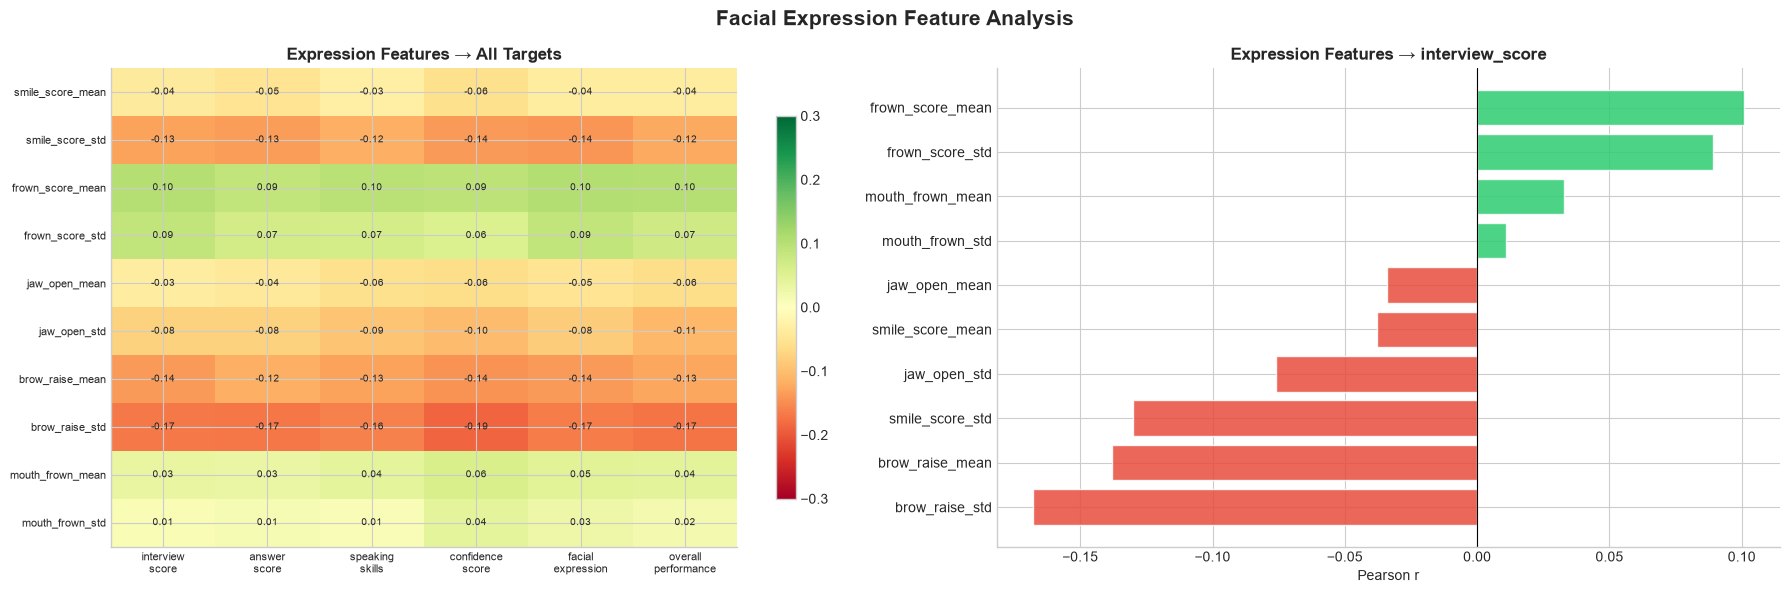


⚠️  Key collinear expression pairs:
   jaw_open_mean vs jaw_open_std       : r = 0.8782
   mouth_frown_mean vs mouth_frown_std : r = 0.9025
   brow_raise_mean vs brow_raise_std   : r = 0.5324


In [22]:
avail_t = [c for c in ALL_TARGETS if c in df.columns]
e_corr  = df[avail_e + avail_t].corr().loc[avail_e, avail_t].round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Correlation heatmap expressions vs targets
im = axes[0].imshow(e_corr.values, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')
axes[0].set_xticks(range(len(avail_t))); axes[0].set_yticks(range(len(avail_e)))
axes[0].set_xticklabels([c.replace('_','\n') for c in avail_t], fontsize=8)
axes[0].set_yticklabels(avail_e, fontsize=8)
for i in range(len(avail_e)):
    for j in range(len(avail_t)):
        axes[0].text(j, i, f'{e_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title('Expression Features → All Targets', fontsize=12)

# Expression vs interview_score bar
ec_bar = e_corr['interview_score'].sort_values()
cb = ['#e74c3c' if v < 0 else '#2ecc71' for v in ec_bar.values]
axes[1].barh(ec_bar.index, ec_bar.values, color=cb, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Expression Features → interview_score', fontsize=12)
axes[1].set_xlabel('Pearson r')

plt.suptitle('Facial Expression Feature Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Key collinearities
print("\n⚠️  Key collinear expression pairs:")
print(f"   jaw_open_mean vs jaw_open_std       : r = {df['jaw_open_mean'].corr(df['jaw_open_std']):.4f}")
print(f"   mouth_frown_mean vs mouth_frown_std : r = {df['mouth_frown_mean'].corr(df['mouth_frown_std']):.4f}")
print(f"   brow_raise_mean vs brow_raise_std   : r = {df['brow_raise_mean'].corr(df['brow_raise_std']):.4f}")


## 11. Facial: Emotion Probabilities <a id='emotions'></a>

Seven per-frame emotion classifier outputs averaged across the clip.  
These overlap heavily with expression AU features — expect collinearity.


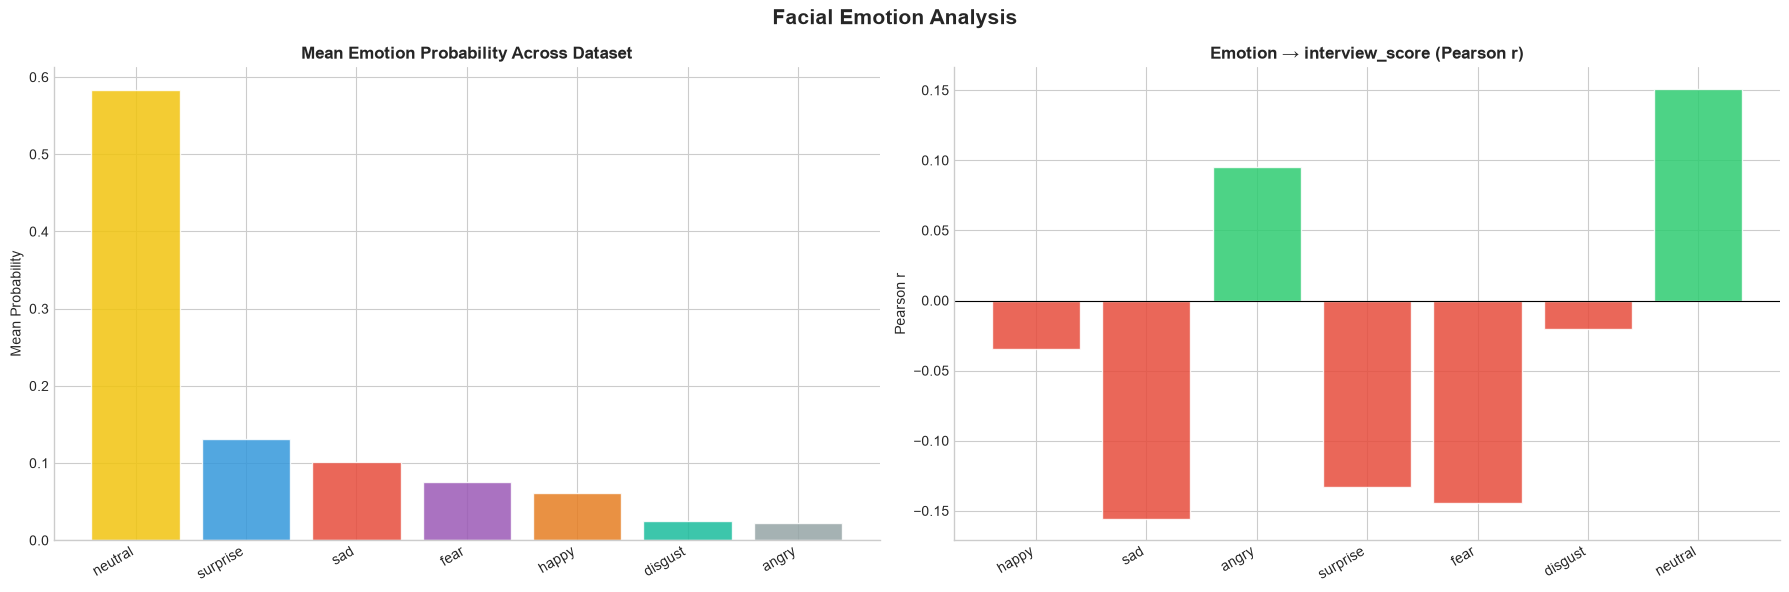


⚠️  Emotion vs Expression collinearity (DROP these emotion columns):
   smile_score_mean vs emotion_happy_mean    : r = 0.9964
   frown_score_mean vs emotion_angry_mean    : r = 0.9844
   brow_raise_mean  vs emotion_surprise_mean : r = 0.9767
   emotion_sad_mean vs emotion_fear_mean     : r = 0.9871


In [23]:
avail_em = [c for c in FACE_EMOTION if c in df.columns]
avail_t  = [c for c in ALL_TARGETS if c in df.columns]

# Mean emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
emo_means = df[avail_em].mean().sort_values(ascending=False)
ec   = ['#f1c40f','#3498db','#e74c3c','#9b59b6','#e67e22','#1abc9c','#95a5a6']
axes[0].bar(range(len(emo_means)), emo_means.values, color=ec[:len(emo_means)], edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(len(emo_means)))
axes[0].set_xticklabels([e.replace('emotion_','').replace('_mean','') for e in emo_means.index], rotation=30, ha='right')
axes[0].set_title('Mean Emotion Probability Across Dataset', fontsize=12)
axes[0].set_ylabel('Mean Probability')

# Emotion vs interview_score
em_corr = df[avail_em + ['interview_score']].corr()['interview_score'].drop('interview_score')
cb2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in em_corr.values]
axes[1].bar(range(len(em_corr)), em_corr.values, color=cb2, edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(len(em_corr)))
axes[1].set_xticklabels([e.replace('emotion_','').replace('_mean','') for e in em_corr.index], rotation=30, ha='right')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Emotion → interview_score (Pearson r)', fontsize=12)
axes[1].set_ylabel('Pearson r')

plt.suptitle('Facial Emotion Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Collinearity check: emotion vs expression
print("\n⚠️  Emotion vs Expression collinearity (DROP these emotion columns):")
print(f"   smile_score_mean vs emotion_happy_mean    : r = {df['smile_score_mean'].corr(df['emotion_happy_mean']):.4f}")
print(f"   frown_score_mean vs emotion_angry_mean    : r = {df['frown_score_mean'].corr(df['emotion_angry_mean']):.4f}")
print(f"   brow_raise_mean  vs emotion_surprise_mean : r = {df['brow_raise_mean'].corr(df['emotion_surprise_mean']):.4f}")
print(f"   emotion_sad_mean vs emotion_fear_mean     : r = {df['emotion_sad_mean'].corr(df['emotion_fear_mean']):.4f}")


> **📌 Takeaway:** `emotion_neutral_mean` (positive) and `emotion_sad_mean` (negative) are the most predictive.  
> `emotion_happy_mean` ≡ `smile_score_mean` (r=0.9964) — keep expression AU, drop emotion duplicate.  
> The 7 emotions sum to ≈1.0 per frame — they are compositional (keep only 6, drop one).


## 12. Posture & Movement <a id='posture'></a>

14 features from full-body pose estimation: shoulder alignment, head position, hand movement, posture shifts.


In [24]:
avail_pos = [c for c in POSTURE_COLS if c in df.columns]
display(df[avail_pos].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
head_centering_score_mean,2011.0000,0.0293,0.0190,0.0036,0.0160,0.0250,0.0374,0.1641
absolute_shoulder_slope_mean,2011.0000,0.0507,0.0339,0.0069,0.0259,0.0423,0.0655,0.2815
shoulder_slope_var,2011.0000,0.0112,0.3878,0.0000,0.0002,0.0004,0.0007,16.9919
shoulder_width_mean,2011.0000,0.4911,0.1067,0.2487,0.4156,0.4963,0.5647,0.7980
shoulder_width_var,2011.0000,0.0003,0.0007,0.0000,0.0001,0.0001,0.0002,0.0126
nose_shoulder_dist_mean,2011.0000,0.3057,0.0880,0.0290,0.2358,0.3161,0.3746,0.5645
nose_shoulder_dist_var,2011.0000,0.0005,0.0006,0.0000,0.0001,0.0003,0.0006,0.0073
hand_speed_mean,2011.0000,0.0468,0.0426,0.0032,0.0194,0.0304,0.0571,0.3295
hand_to_face_touches,2011.0000,0.0552,0.6209,0.0000,0.0000,0.0000,0.0000,13.0000
crossed_arms_score,2011.0000,0.9176,0.2051,0.3711,0.7687,0.9240,1.0665,1.5611


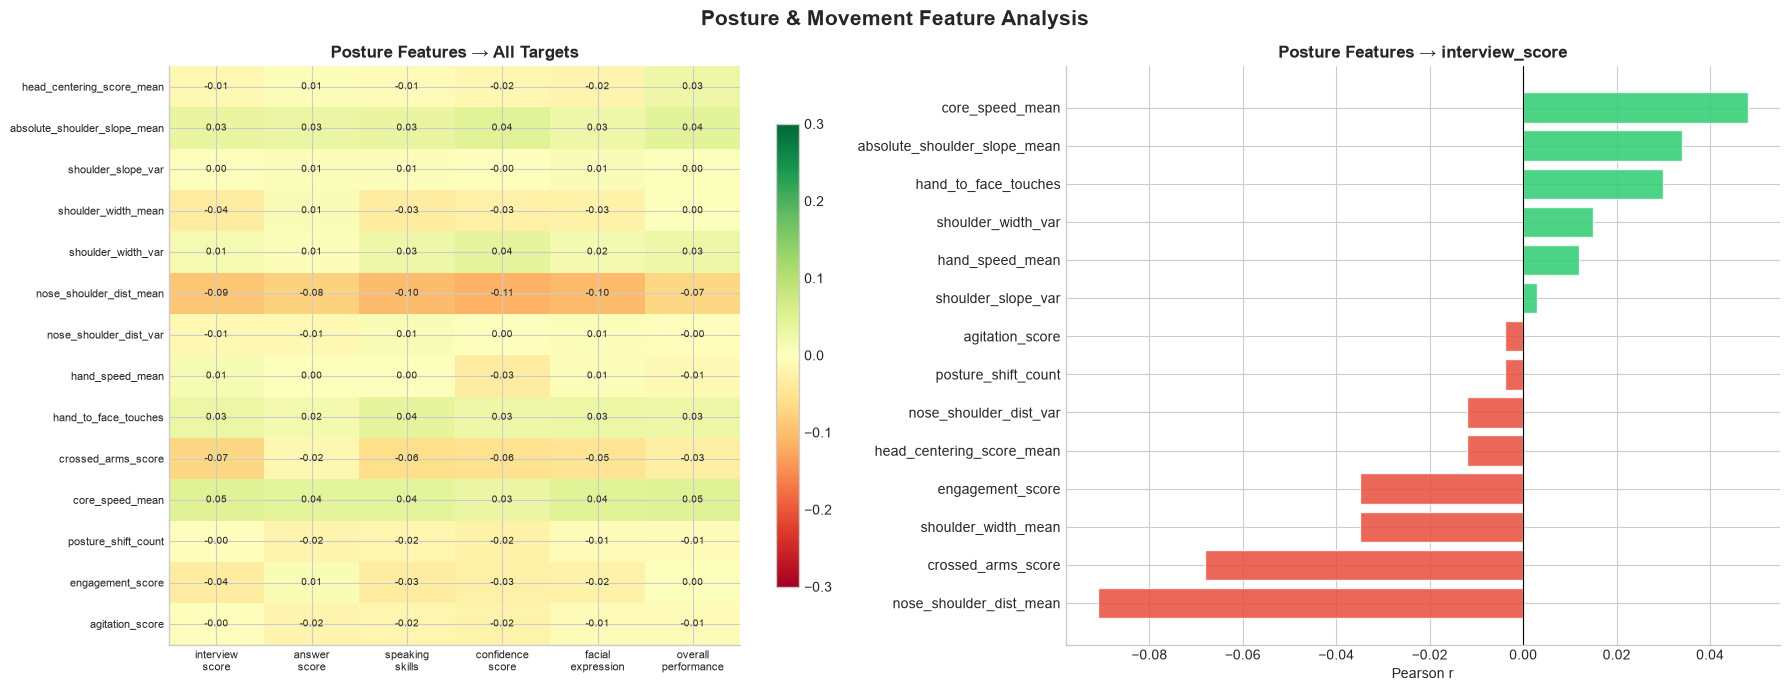


🚨 PERFECT COLLINEARITY:
   shoulder_width_mean vs engagement_score : r = 0.9998  → DROP engagement_score
   posture_shift_count vs agitation_score  : r = 0.9998  → DROP agitation_score


In [25]:
avail_t   = [c for c in ALL_TARGETS if c in df.columns]
pos_corr  = df[avail_pos + avail_t].corr().loc[avail_pos, avail_t].round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

im = axes[0].imshow(pos_corr.values, cmap='RdYlGn', vmin=-0.3, vmax=0.3, aspect='auto')
axes[0].set_xticks(range(len(avail_t))); axes[0].set_yticks(range(len(avail_pos)))
axes[0].set_xticklabels([c.replace('_','\n') for c in avail_t], fontsize=8)
axes[0].set_yticklabels(avail_pos, fontsize=8)
for i in range(len(avail_pos)):
    for j in range(len(avail_t)):
        axes[0].text(j, i, f'{pos_corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title('Posture Features → All Targets', fontsize=12)

pc_bar = pos_corr['interview_score'].sort_values()
cb = ['#e74c3c' if v < 0 else '#2ecc71' for v in pc_bar.values]
axes[1].barh(pc_bar.index, pc_bar.values, color=cb, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Posture Features → interview_score', fontsize=12)
axes[1].set_xlabel('Pearson r')

plt.suptitle('Posture & Movement Feature Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Perfect collinearity flags
r1 = df['shoulder_width_mean'].corr(df['engagement_score'])
r2 = df['posture_shift_count'].corr(df['agitation_score'])
print(f"\n🚨 PERFECT COLLINEARITY:")
print(f"   shoulder_width_mean vs engagement_score : r = {r1:.4f}  → DROP engagement_score")
print(f"   posture_shift_count vs agitation_score  : r = {r2:.4f}  → DROP agitation_score")


## 13. Feature → Target Correlation Ranking (All 6 Targets) <a id='corr-rank'></a>

Rank ALL predictive features by their average absolute Pearson correlation across all 6 targets.  
Use this to quickly identify the best features and weakest features.


In [26]:
avail_t = [c for c in ALL_TARGETS if c in df.columns]
feat_c  = [c for c in ALL_FEATURES if c in df.columns]
cp      = df[feat_c + avail_t].corr()
feat_vs_targets = cp.loc[feat_c, avail_t]
feat_vs_targets['avg_abs_r'] = feat_vs_targets.abs().mean(axis=1)
feat_vs_targets = feat_vs_targets.sort_values('avg_abs_r', ascending=False)

print("Top 25 features by average |r| across all 6 targets:")
display(feat_vs_targets.head(25).round(3))


Top 25 features by average |r| across all 6 targets:


,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance,avg_abs_r
overall_personality,0.6470,0.6990,0.6080,0.7230,0.6290,0.7650,0.6790
agreeableness,0.6250,0.6720,0.6280,0.6550,0.6770,0.6480,0.6510
openness,0.6840,0.6210,0.6420,0.6010,0.6390,0.6510,0.6400
extraversion,0.6410,0.6260,0.6240,0.6220,0.6380,0.6100,0.6270
conscientiousness,0.5240,0.6510,0.5330,0.6150,0.5330,0.6690,0.5870
Duration_Sec,-0.3490,-0.3710,-0.3290,-0.3210,-0.3280,-0.3670,0.3440
neuroticism,-0.2310,-0.3170,-0.2450,-0.3530,-0.2650,-0.3290,0.2900
Silence_Duration_Sec,-0.2680,-0.2900,-0.2600,-0.2510,-0.2500,-0.2920,0.2680
Mean_Energy,-0.1900,-0.1910,-0.1850,-0.2240,-0.1870,-0.1950,0.1950
MFCC_1,-0.1850,-0.1880,-0.1800,-0.1820,-0.1770,-0.1800,0.1820


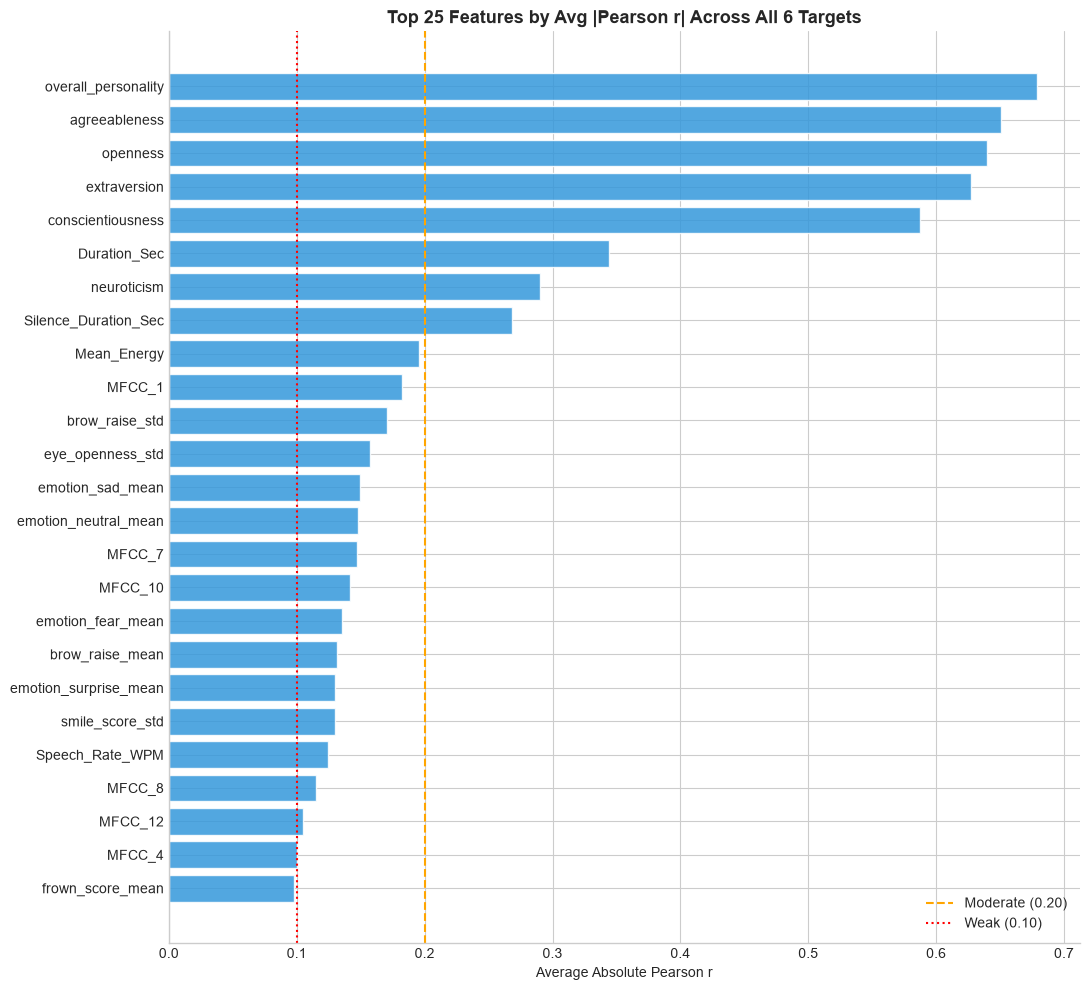

In [27]:
# Visual: Top 25 avg |r| bar
top25 = feat_vs_targets['avg_abs_r'].head(25).sort_values()
fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(top25.index, top25.values, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.20, color='orange', lw=1.5, ls='--', label='Moderate (0.20)')
ax.axvline(0.10, color='red',    lw=1.5, ls=':',  label='Weak (0.10)')
ax.set_title('Top 25 Features by Avg |Pearson r| Across All 6 Targets', fontsize=13)
ax.set_xlabel('Average Absolute Pearson r')
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
# Bottom 15 (weakest predictors)
print("Bottom 15 weakest features (lowest avg |r|):")
display(feat_vs_targets.tail(15)[['interview_score','avg_abs_r']].round(4))


Bottom 15 weakest features (lowest avg |r|):


,interview_score,avg_abs_r
Mean_Pitch_Hz,-0.0009,0.0277
engagement_score,-0.0347,0.0224
shoulder_width_mean,-0.0348,0.0224
shoulder_width_var,0.0155,0.0219
mouth_frown_std,0.0108,0.0196
Mean_ZCR,0.0015,0.0180
MFCC_2,-0.0079,0.0169
head_centering_score_mean,-0.0118,0.0153
MFCC_6,-0.0136,0.0147
posture_shift_count,-0.0043,0.0136


## 14. Multicollinearity & Redundancy Detection <a id='collinearity'></a>

Collinear features don't add new information — they inflate model complexity and harm interpretability.  
We identify pairs at multiple thresholds and give concrete drop decisions.


In [29]:
feat_c = [c for c in ALL_FEATURES if c in df.columns]
cm_abs = df[feat_c].corr().abs()
tri    = cm_abs.where(np.triu(np.ones(cm_abs.shape), k=1).astype(bool))

for thresh in [0.95, 0.90, 0.85]:
    pairs = [(r, col, round(float(tri.loc[r, col]), 4))
             for col in tri.columns for r in tri.index if tri.loc[r, col] > thresh]
    pairs.sort(key=lambda x: -x[2])
    print(f"\n|r| > {thresh:.2f}  =>  {len(pairs)} pairs:")
    if pairs:
        pdf = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', '|r|'])
        display(pdf)



|r| > 0.95  =>  6 pairs:


,Feature A,Feature B,|r|
0,shoulder_width_mean,engagement_score,0.9998
1,posture_shift_count,agitation_score,0.9998
2,smile_score_mean,emotion_happy_mean,0.9964
3,emotion_sad_mean,emotion_fear_mean,0.9871
4,frown_score_mean,emotion_angry_mean,0.9844
5,brow_raise_mean,emotion_surprise_mean,0.9767



|r| > 0.90  =>  8 pairs:


,Feature A,Feature B,|r|
0,shoulder_width_mean,engagement_score,0.9998
1,posture_shift_count,agitation_score,0.9998
2,smile_score_mean,emotion_happy_mean,0.9964
3,emotion_sad_mean,emotion_fear_mean,0.9871
4,frown_score_mean,emotion_angry_mean,0.9844
5,brow_raise_mean,emotion_surprise_mean,0.9767
6,gaze_ratio_mean,gaze_deviation_mean,0.9132
7,mouth_frown_mean,mouth_frown_std,0.9025



|r| > 0.85  =>  12 pairs:


,Feature A,Feature B,|r|
0,shoulder_width_mean,engagement_score,0.9998
1,posture_shift_count,agitation_score,0.9998
2,smile_score_mean,emotion_happy_mean,0.9964
3,emotion_sad_mean,emotion_fear_mean,0.9871
4,frown_score_mean,emotion_angry_mean,0.9844
5,brow_raise_mean,emotion_surprise_mean,0.9767
6,gaze_ratio_mean,gaze_deviation_mean,0.9132
7,mouth_frown_mean,mouth_frown_std,0.9025
8,jaw_open_mean,jaw_open_std,0.8782
9,crossed_arms_score,engagement_score,0.8616


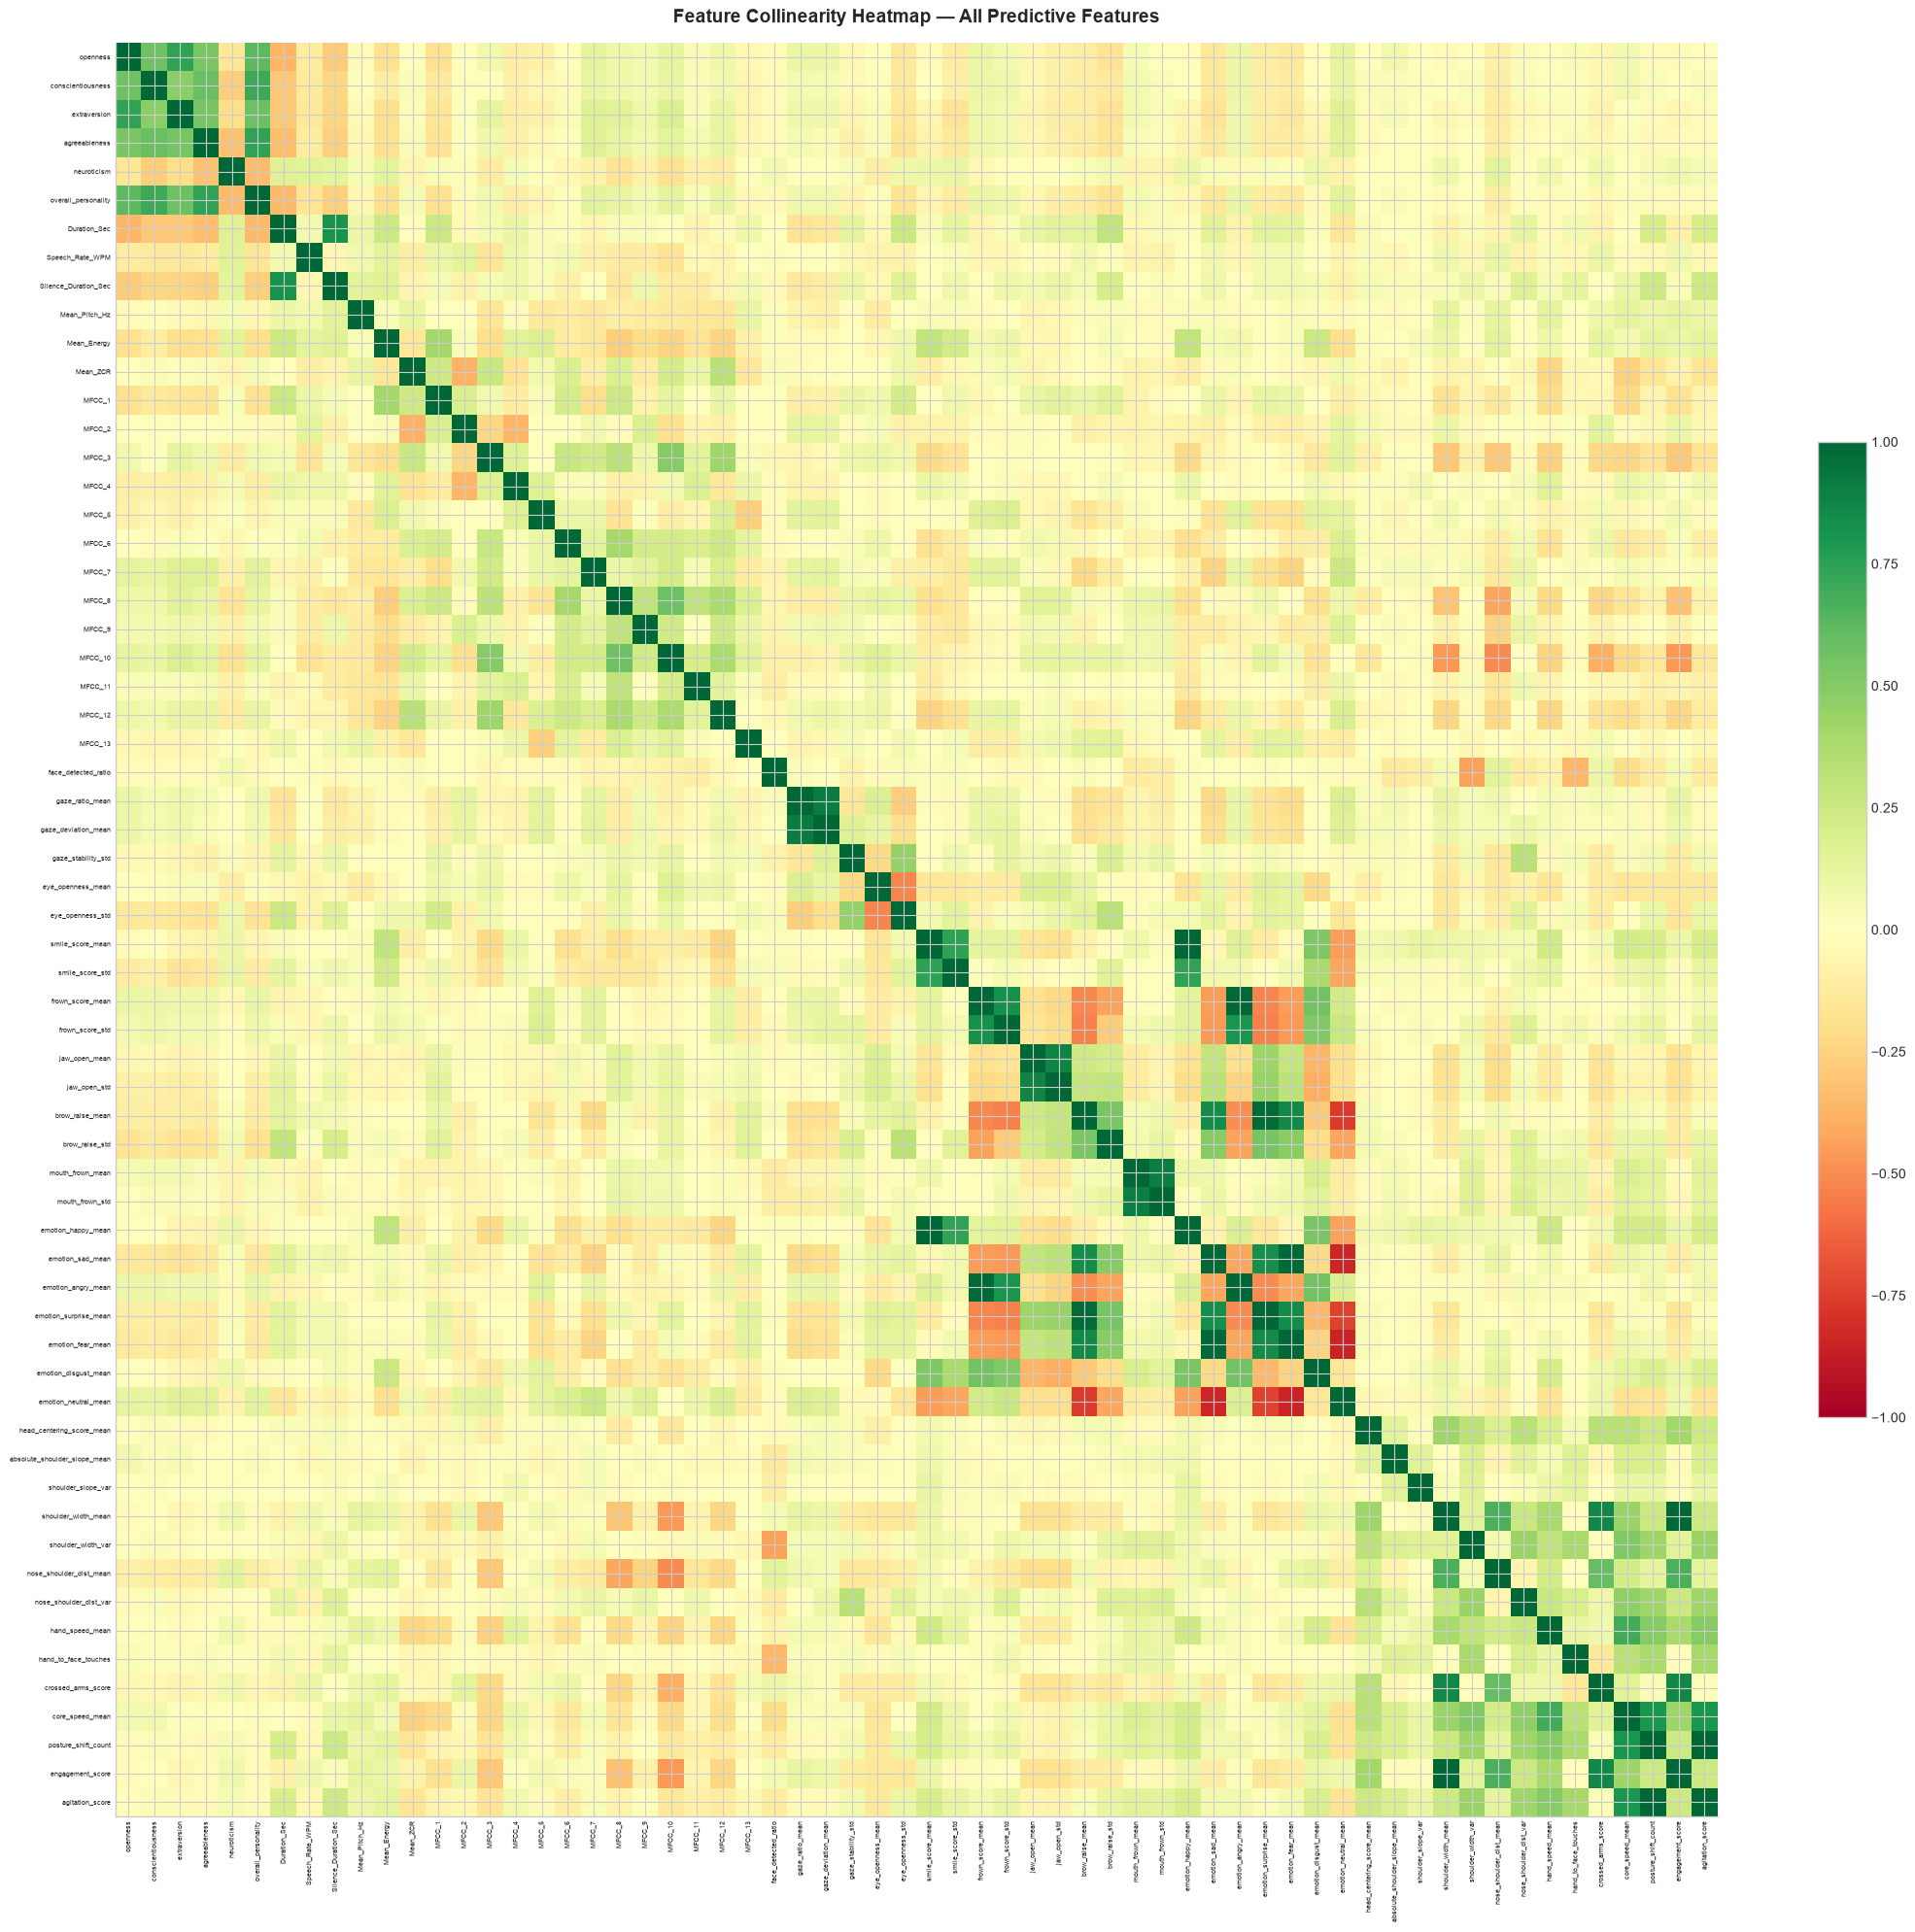

In [30]:
# Full collinearity heatmap (all features)
fig, ax = plt.subplots(figsize=(22, 20))
cf = df[feat_c].corr()
im = ax.imshow(cf.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(feat_c))); ax.set_yticks(range(len(feat_c)))
ax.set_xticklabels(feat_c, fontsize=5, rotation=90)
ax.set_yticklabels(feat_c, fontsize=5)
plt.colorbar(im, ax=ax, shrink=0.55)
ax.set_title('Feature Collinearity Heatmap — All Predictive Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## 15. Low-Variance Feature Audit <a id='low-var'></a>

Near-zero variance features carry no signal — they are essentially constant and should be dropped before modelling.


In [34]:
feat_c = [c for c in ALL_FEATURES if c in df.columns]
var_df = pd.DataFrame({
    'Feature':       feat_c,
    'Variance':      [df[c].var() for c in feat_c],
    'Std':           [df[c].std() for c in feat_c],
    'Unique_Values': [df[c].nunique() for c in feat_c],
}).sort_values('Variance')

var_df['Flag'] = var_df['Variance'].apply(
    lambda v: '🔴 DROP (near-zero var)' if v < 1e-4 else '🟡 WARN (low var)' if v < 0.01 else '✅')

print("Features sorted by variance (ascending):")
display(var_df.style.map(
    lambda v: 'background-color: #ffcccc' if 'DROP' in str(v) else
              'background-color: #fff3cc' if 'WARN' in str(v) else '',
    subset=['Flag']))


Features sorted by variance (ascending):


,Feature,Variance,Std,Unique_Values,Flag
54,nose_shoulder_dist_var,0.000000,0.000595,2001,🔴 DROP (near-zero var)
52,shoulder_width_var,0.000001,0.000733,2001,🔴 DROP (near-zero var)
58,core_speed_mean,0.000016,0.004035,2001,🔴 DROP (near-zero var)
39,mouth_frown_mean,0.000053,0.007287,2001,🔴 DROP (near-zero var)
40,mouth_frown_std,0.000104,0.010192,1983,🟡 WARN (low var)
28,gaze_stability_std,0.000143,0.011939,1983,🟡 WARN (low var)
10,Mean_Energy,0.000189,0.013731,450,🟡 WARN (low var)
27,gaze_deviation_mean,0.000268,0.016374,2001,🟡 WARN (low var)
26,gaze_ratio_mean,0.000338,0.018389,2001,🟡 WARN (low var)
48,head_centering_score_mean,0.000362,0.019035,2001,🟡 WARN (low var)


## 16. Outlier Audit <a id='outliers'></a>

IQR 1.5× and Z-score >3 outlier counts per feature.  
Features with >10% outliers need clipping or log-transformation before modelling.


In [36]:
feat_c  = [c for c in ALL_FEATURES if c in df.columns]
avail_t = [c for c in ALL_TARGETS if c in df.columns]
all_c   = feat_c + avail_t
n       = len(df)
records = []
for c in all_c:
    s = df[c]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_iqr = int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
    n_z   = int((np.abs((s-s.mean())/s.std()) > 3).sum())
    records.append({'Feature': c, 'IQR Outliers': n_iqr, 'IQR %': round(n_iqr/n*100,2),
                    'Z>3 Outliers': n_z, 'Z %': round(n_z/n*100,2)})

out_df = pd.DataFrame(records).sort_values('IQR %', ascending=False)
out_df['Action'] = out_df['IQR %'].apply(
    lambda p: '🔴 SEVERE — clip/log' if p > 10 else '🟡 MODERATE — consider cap' if p > 5 else '✅')

display(out_df.style.map(
    lambda v: 'background-color: #ffcccc' if 'SEVERE' in str(v) else
              'background-color: #fff3cc' if 'MODERATE' in str(v) else '',
    subset=['Action']))


,Feature,IQR Outliers,IQR %,Z>3 Outliers,Z %,Action
61,agitation_score,274,13.630000,52,2.590000,🔴 SEVERE — clip/log
59,posture_shift_count,274,13.630000,52,2.590000,🔴 SEVERE — clip/log
39,mouth_frown_mean,270,13.430000,50,2.490000,🔴 SEVERE — clip/log
33,frown_score_mean,246,12.230000,62,3.080000,🔴 SEVERE — clip/log
40,mouth_frown_std,242,12.030000,55,2.730000,🔴 SEVERE — clip/log
52,shoulder_width_var,225,11.190000,28,1.390000,🔴 SEVERE — clip/log
43,emotion_angry_mean,225,11.190000,57,2.830000,🔴 SEVERE — clip/log
41,emotion_happy_mean,211,10.490000,59,2.930000,🔴 SEVERE — clip/log
31,smile_score_mean,200,9.950000,55,2.730000,🟡 MODERATE — consider cap
55,hand_speed_mean,190,9.450000,43,2.140000,🟡 MODERATE — consider cap


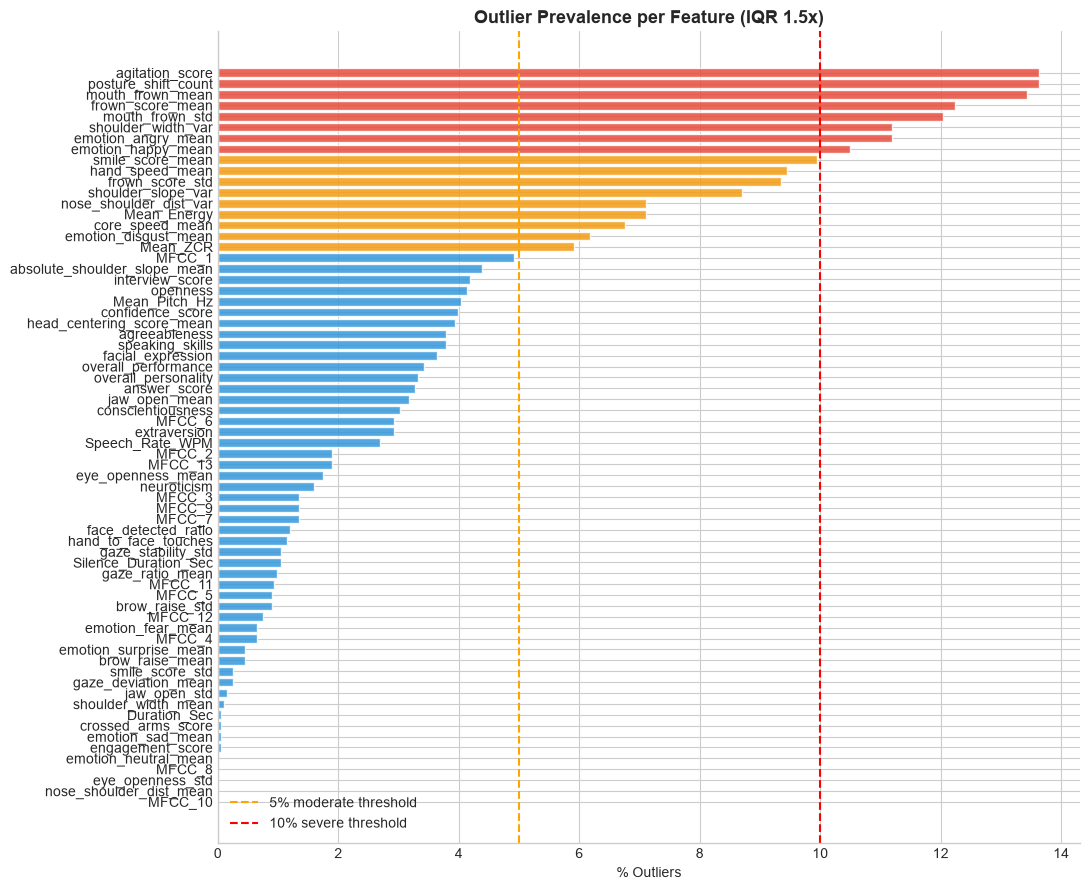

In [37]:
# Visual: Outlier prevalence bar chart
fig, ax = plt.subplots(figsize=(11, 9))
od = out_df.set_index('Feature')['IQR %'].sort_values()
cb = ['#e74c3c' if v>10 else '#f39c12' if v>5 else '#3498db' for v in od.values]
ax.barh(od.index, od.values, color=cb, edgecolor='white', alpha=0.85)
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='5% moderate threshold')
ax.axvline(10, color='red',    lw=1.5, ls='--', label='10% severe threshold')
ax.set_title('Outlier Prevalence per Feature (IQR 1.5x)', fontsize=13)
ax.set_xlabel('% Outliers')
ax.legend()
plt.tight_layout()
plt.show()


## 17. Categorical Analysis <a id='categorical'></a>

Three categorical variables in the dataset: `duration_label`, `video_quality`, `question_id`.


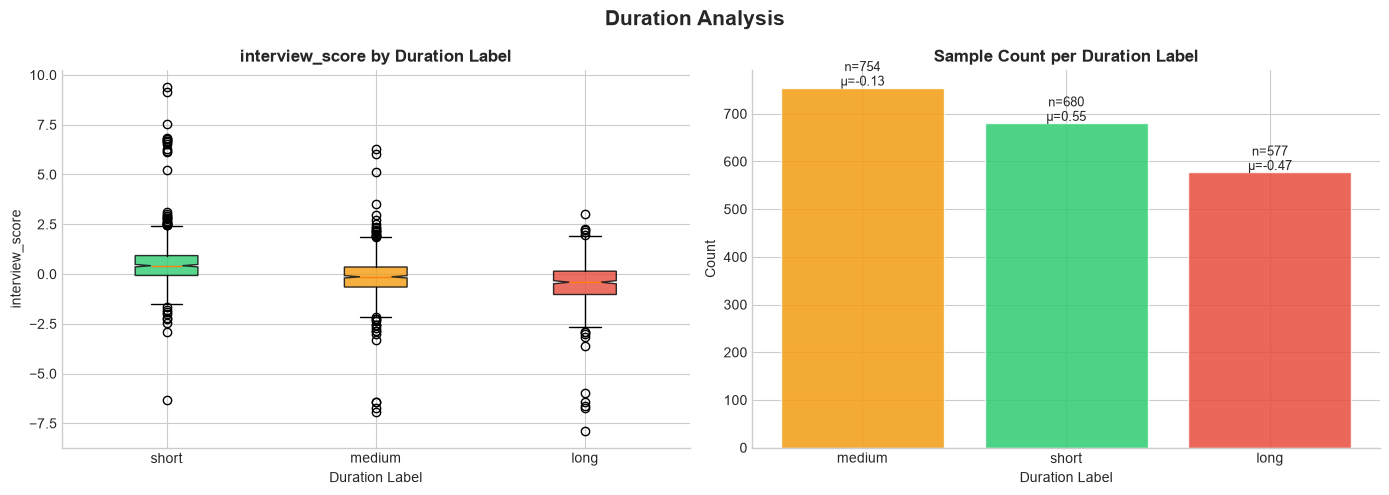


Duration Label stats:


interview_score                answer_score                speaking_skills                confidence_score                facial_expression  \
                         count    mean    std        count    mean    std           count    mean    std            count    mean    std             count   
duration_label                                                                                                                                               
long                       577 -0.4720 1.0960          577 -0.4740 1.1200             577 -0.4690 1.3530              577 -0.3790 1.1740               577   
medium                     754 -0.1320 1.0680          754 -0.1160 0.9950             754 -0.1380 1.1870              754 -0.1000 0.9690               754   
short                      680  0.5470 1.2990          680  0.5310 1.2000             680  0.5510 1.0970              680  0.4320 0.9590               680   

                              overall_performance                Duration_Sec                Silence_Duration_Sec                 
                  mean    std               count    mean    std        count    mean    std                count    mean    std  
duration_label                                                                                                                    
long           -0.4330 1.0750                 577 -0.4960 1.2330          577 51.2700 6.8960                  577 14.4070 4.7560  
medium         -0.0820 1.0290                 754 -0.1190 1.1140          754 28.7350 5.6240                  754  8.3100 3.2520  
short           0.4590 1.1790                 680  0.5530 1.0340          680 12.3540 4.7580                  680  3.6740 2.1420

In [38]:
avail_t = [c for c in ALL_TARGETS if c in df.columns]
# ── 17A. Duration Label ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dorder = [d for d in ['short','medium','long'] if d in df['duration_label'].unique()]
data   = [df[df['duration_label']==d]['interview_score'].dropna().values for d in dorder]
bp     = axes[0].boxplot(data, patch_artist=True, notch=True, tick_labels=dorder)
for patch, c in zip(bp['boxes'], ['#2ecc71','#f39c12','#e74c3c']):
    patch.set_facecolor(c); patch.set_alpha(0.8)
axes[0].set_title('interview_score by Duration Label', fontsize=12)
axes[0].set_xlabel('Duration Label'); axes[0].set_ylabel('interview_score')

counts = df['duration_label'].value_counts()
axes[1].bar(counts.index, counts.values,
            color=['#2ecc71' if d=='short' else '#f39c12' if d=='medium' else '#e74c3c' for d in counts.index],
            edgecolor='white', alpha=0.85)
for i, (d, v) in enumerate(counts.items()):
    avg = df[df['duration_label']==d]['interview_score'].mean()
    axes[1].text(i, v+5, f'n={v}\nμ={avg:.2f}', ha='center', fontsize=9)
axes[1].set_title('Sample Count per Duration Label', fontsize=12)
axes[1].set_xlabel('Duration Label'); axes[1].set_ylabel('Count')

plt.suptitle('Duration Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDuration Label stats:")
display(df.groupby('duration_label')[avail_t + ['Duration_Sec','Silence_Duration_Sec']].agg(['count','mean','std']).round(3))


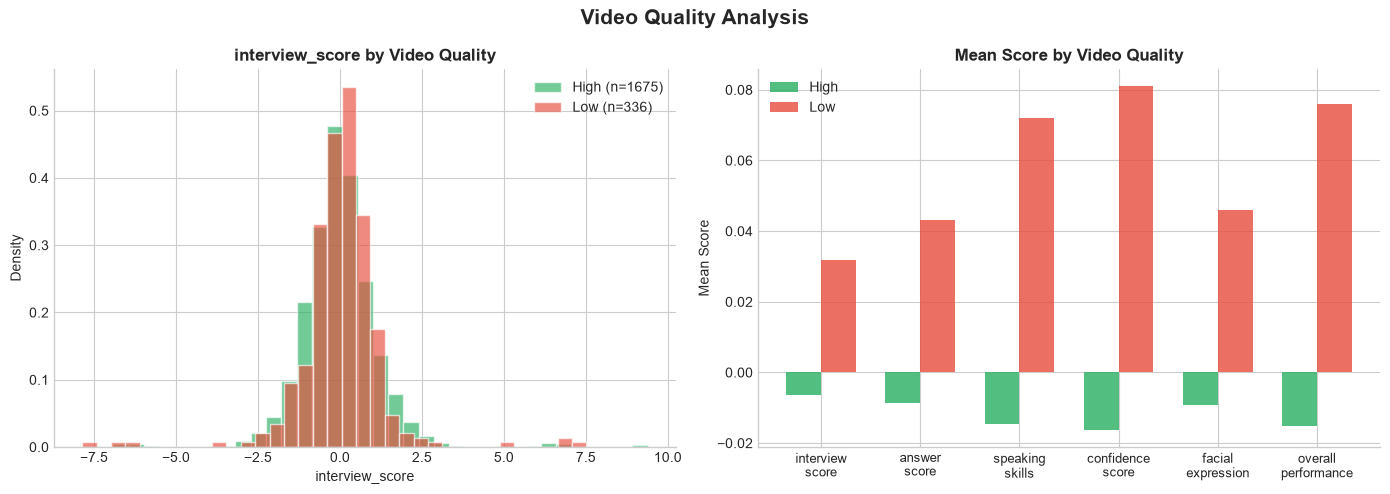


Video Quality distribution: {'High': 1675, 'Low': 336}
Note: Negligible score difference between High/Low quality → EXCLUDE from model features


In [39]:
# ── 17B. Video Quality ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for qual, color in [('High','#27ae60'),('Low','#e74c3c')]:
    s = df[df['video_quality']==qual]['interview_score'].dropna()
    axes[0].hist(s, bins=35, label=f'{qual} (n={len(s)})',
                 color=color, alpha=0.65, edgecolor='white', density=True)
axes[0].set_title('interview_score by Video Quality', fontsize=12)
axes[0].legend(); axes[0].set_xlabel('interview_score'); axes[0].set_ylabel('Density')

vq_means = df.groupby('video_quality')[avail_t].mean()
x = np.arange(len(avail_t)); w = 0.35
axes[1].bar(x-w/2, vq_means.loc['High'], w, label='High', color='#27ae60', alpha=0.8)
axes[1].bar(x+w/2, vq_means.loc['Low'],  w, label='Low',  color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([t.replace('_','\n') for t in avail_t], fontsize=9)
axes[1].set_title('Mean Score by Video Quality', fontsize=12)
axes[1].legend(); axes[1].set_ylabel('Mean Score')

plt.suptitle('Video Quality Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nVideo Quality distribution: {df['video_quality'].value_counts().to_dict()}")
print("Note: Negligible score difference between High/Low quality → EXCLUDE from model features")


Total unique questions : 76

Top 10 questions with highest score variance (harder to score consistently):


,n_samples,mean_score,std_score,mean_duration
question_id,,,,
67,17,0.0000,3.0360,28.3940
33,17,0.0000,2.9080,19.6980
32,18,-0.0000,2.8260,25.1430
7,18,-0.0000,2.3100,32.1740
59,19,0.0000,2.0850,36.4860
75,18,0.0000,2.0740,33.0890
65,14,-0.0000,2.0280,37.9210
34,17,-0.0000,2.0060,26.0880
36,17,0.0000,1.9920,28.0230


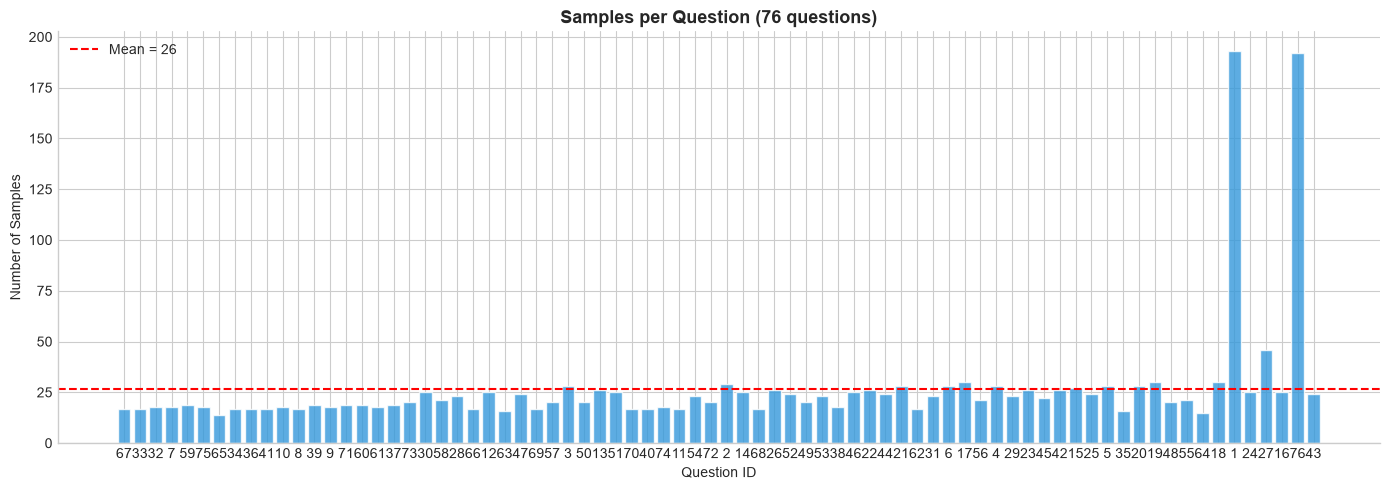

In [40]:
# ── 17C. Question Analysis ─────────────────────────────────────────────────
q_stats = df.groupby('question_id').agg(
    n_samples     =('id', 'count'),
    mean_score    =('interview_score', 'mean'),
    std_score     =('interview_score', 'std'),
    mean_duration =('Duration_Sec', 'mean'),
).sort_values('std_score', ascending=False)

print(f"Total unique questions : {df['question_id'].nunique()}")
print(f"\nTop 10 questions with highest score variance (harder to score consistently):")
display(q_stats.head(10).round(3))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(q_stats.index.astype(str), q_stats['n_samples'],
       color='#3498db', edgecolor='white', alpha=0.8)
ax.set_title(f'Samples per Question ({df["question_id"].nunique()} questions)', fontsize=13)
ax.set_xlabel('Question ID')
ax.set_ylabel('Number of Samples')
ax.axhline(q_stats['n_samples'].mean(), color='red', lw=1.5, ls='--',
           label=f"Mean = {q_stats['n_samples'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()


## 18. Candidate (user_no) Level Analysis <a id='candidates'></a>

Each `user_no` is a unique candidate who answered multiple interview questions.  
This is critical for **preventing data leakage** in cross-validation.


In [41]:
user_stats = df.groupby('user_no').agg(
    n_samples    =('id', 'count'),
    n_questions  =('question_id', 'nunique'),
    mean_score   =('interview_score', 'mean'),
    std_score    =('interview_score', 'std'),
    mean_overall =('overall_performance', 'mean'),
    mean_conf    =('confidence_score', 'mean'),
).sort_values('n_samples', ascending=False)

nu     = df['user_no'].nunique()
single = (user_stats['n_samples'] == 1).sum()
print(f"Total unique candidates  : {nu}")
print(f"Samples per candidate    : min={user_stats['n_samples'].min()}, "
      f"max={user_stats['n_samples'].max()}, mean={user_stats['n_samples'].mean():.1f}")
print(f"Candidates with 1 sample : {single} ({single/nu*100:.1f}%) — risk in GroupKFold")

print("\nTop 20 candidates by sample count:")
display(user_stats.head(20).round(3))


Total unique candidates  : 331
Samples per candidate    : min=1, max=17, mean=6.1
Candidates with 1 sample : 11 (3.3%) — risk in GroupKFold

Top 20 candidates by sample count:


,n_samples,n_questions,mean_score,std_score,mean_overall,mean_conf
user_no,,,,,,
163,17,14,0.3980,0.7400,0.5770,0.3180
296,12,11,0.1440,0.8740,0.1160,0.0560
222,12,12,-0.4610,0.8040,-0.4470,-0.2660
318,12,11,-0.0570,0.6940,0.0860,0.2140
314,11,10,-0.3890,0.6350,-0.3760,-0.2780
331,9,7,0.0530,0.6100,0.0520,-0.2100
212,9,9,-1.4650,0.6610,-1.2780,-1.3650
223,9,7,-0.7380,1.1260,-0.5560,-0.4900
326,9,9,1.6030,2.1500,0.7470,0.9230


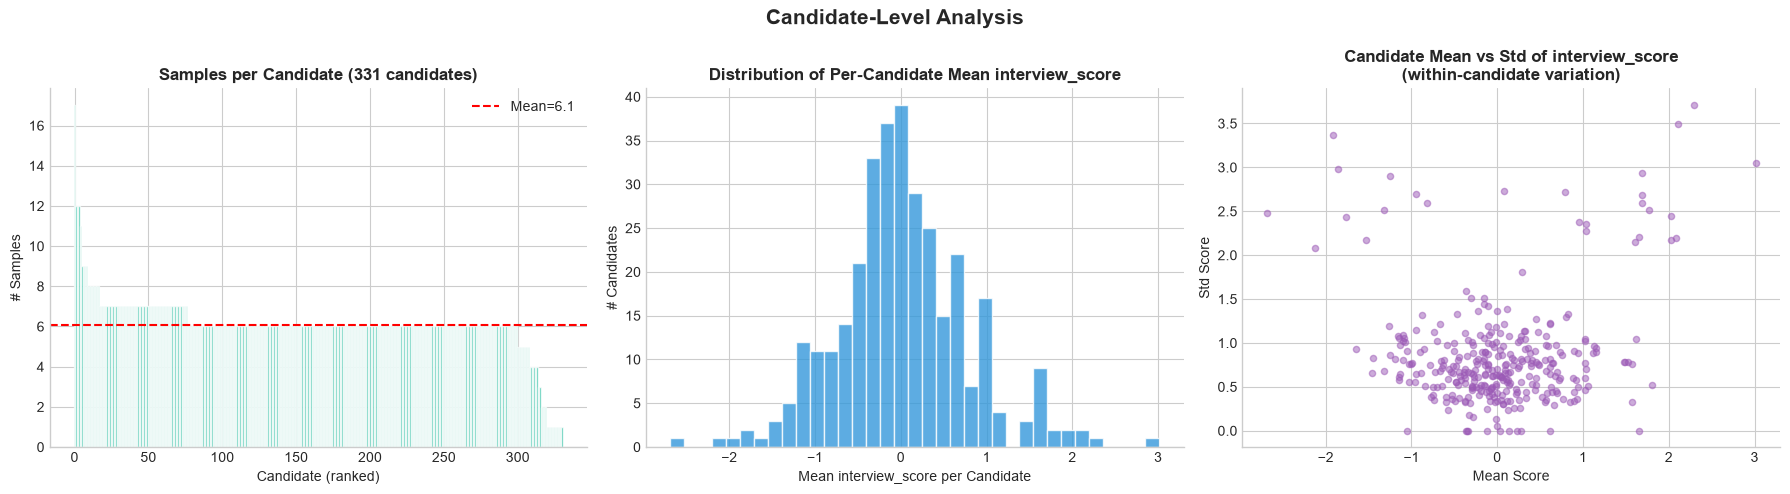


Variance decomposition for interview_score:
  Within-candidate variance  : 1.1489 (75.9% of total)
  Between-candidate variance : 0.6030 (39.9% of total)

🔴 CRITICAL: Use GroupKFold(groups=user_no) in cross-validation to prevent candidate leakage!


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Samples per candidate
spu = df['user_no'].value_counts().sort_values(ascending=False)
axes[0].bar(range(len(spu)), spu.values, color='#1abc9c', edgecolor='white', alpha=0.8)
axes[0].axhline(spu.mean(), color='red', lw=1.5, ls='--', label=f'Mean={spu.mean():.1f}')
axes[0].set_title(f'Samples per Candidate ({nu} candidates)', fontsize=12)
axes[0].set_xlabel('Candidate (ranked)'); axes[0].set_ylabel('# Samples'); axes[0].legend()

# Per-candidate mean score distribution
axes[1].hist(user_stats['mean_score'], bins=35, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Per-Candidate Mean interview_score', fontsize=12)
axes[1].set_xlabel('Mean interview_score per Candidate'); axes[1].set_ylabel('# Candidates')

# Mean vs Std scatter
axes[2].scatter(user_stats['mean_score'], user_stats['std_score'].fillna(0),
                alpha=0.5, s=20, color='#9b59b6')
axes[2].set_title('Candidate Mean vs Std of interview_score\n(within-candidate variation)', fontsize=12)
axes[2].set_xlabel('Mean Score'); axes[2].set_ylabel('Std Score')

plt.suptitle('Candidate-Level Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Within vs between variance decomposition
within_var  = df.groupby('user_no')['interview_score'].var().mean()
between_var = user_stats['mean_score'].var()
total_var   = df['interview_score'].var()
print(f"\nVariance decomposition for interview_score:")
print(f"  Within-candidate variance  : {within_var:.4f} ({within_var/total_var*100:.1f}% of total)")
print(f"  Between-candidate variance : {between_var:.4f} ({between_var/total_var*100:.1f}% of total)")
print(f"\n🔴 CRITICAL: Use GroupKFold(groups=user_no) in cross-validation to prevent candidate leakage!")


## 19. Transcript Analysis <a id='transcripts'></a>

Raw text transcripts cannot be used directly — they need an NLP pipeline (TF-IDF, BERT, etc.).  
Here we analyse word count as a proxy feature, and check its correlation with all 6 targets.


Missing transcripts    : 13 (0.65%)
Valid transcript rows  : 1998

Word Count stats:


,count,mean,std,min,25%,50%,75%,max
word_count,1998.0000,82.4300,50.8800,4.0000,41.0000,72.0000,115.0000,256.0000


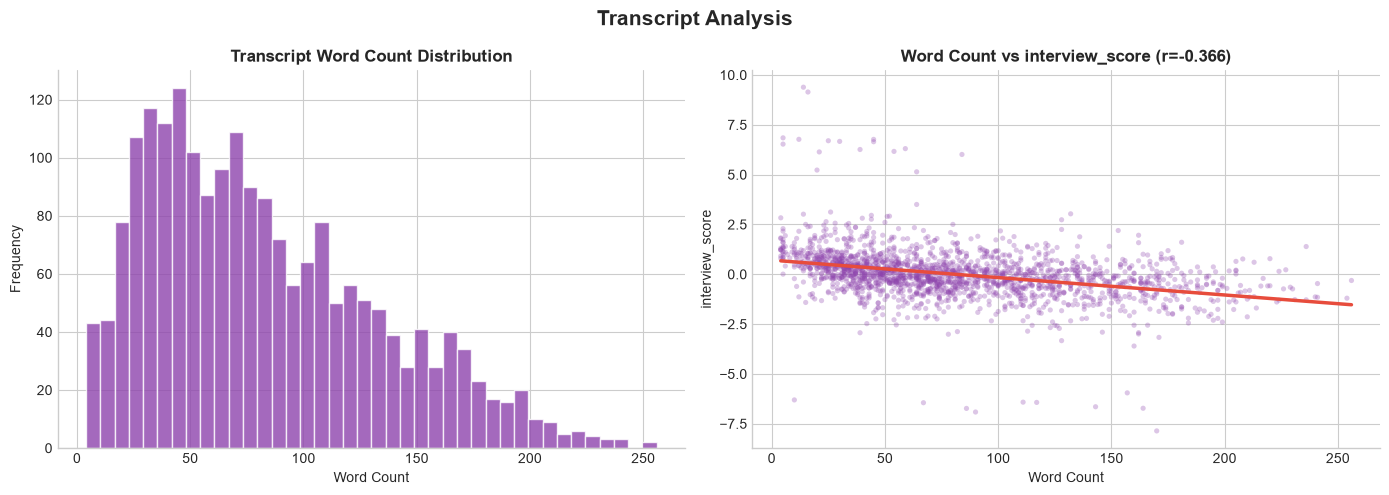


Word Count → All Target Correlations:


,Pearson_r,Spearman_rho
interview_score,-0.3656,-0.4375
answer_score,-0.3822,-0.4510
speaking_skills,-0.3480,-0.4211
confidence_score,-0.3485,-0.3971
facial_expression,-0.3511,-0.4008
overall_performance,-0.3797,-0.4637



📌 Word count negatively correlates (r≈-0.35 to -0.38) with ALL targets.
   Longer, rambling answers → lower scores across every assessment dimension.


In [43]:
avail_t = [c for c in ALL_TARGETS if c in df.columns]
n_miss  = df['transcript'].isnull().sum()
valid   = df.dropna(subset=['transcript']).copy()
valid['word_count'] = valid['transcript'].apply(lambda x: len(str(x).split()))
valid['char_count'] = valid['transcript'].apply(lambda x: len(str(x)))

print(f"Missing transcripts    : {n_miss} ({n_miss/len(df)*100:.2f}%)")
print(f"Valid transcript rows  : {len(valid)}")
print(f"\nWord Count stats:")
display(valid['word_count'].describe().round(2).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(valid['word_count'], bins=40, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[0].set_title('Transcript Word Count Distribution', fontsize=12)
axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')

axes[1].scatter(valid['word_count'], valid['interview_score'],
                alpha=0.3, s=14, color='#8e44ad', edgecolors='none')
m, b = np.polyfit(valid['word_count'], valid['interview_score'], 1)
xf = np.linspace(valid['word_count'].min(), valid['word_count'].max(), 200)
axes[1].plot(xf, m*xf+b, color='#e74c3c', lw=2.5)
r = valid['word_count'].corr(valid['interview_score'])
axes[1].set_title(f'Word Count vs interview_score (r={r:.3f})', fontsize=12)
axes[1].set_xlabel('Word Count'); axes[1].set_ylabel('interview_score')

plt.suptitle('Transcript Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nWord Count → All Target Correlations:")
wc_corrs = pd.DataFrame({
    'Pearson_r':    [valid['word_count'].corr(valid[t]) for t in avail_t],
    'Spearman_rho': [valid['word_count'].corr(valid[t], method='spearman') for t in avail_t]
}, index=avail_t).round(4)
display(wc_corrs)
print("\n📌 Word count negatively correlates (r≈-0.35 to -0.38) with ALL targets.")
print("   Longer, rambling answers → lower scores across every assessment dimension.")


## 20. Skewness & Transformation Recommendations <a id='skewness'></a>

Linear models (Ridge, Lasso, SVM-RBF) are sensitive to skewed features.  
Tree-based models (XGBoost, LightGBM, RF) are robust — but transformations can still help.


In [45]:
feat_c = [c for c in ALL_FEATURES if c in df.columns]
skew_df = pd.DataFrame({
    'Feature': feat_c,
    'Skewness': [df[c].skew() for c in feat_c],
    'Abs_Skew': [abs(df[c].skew()) for c in feat_c],
}).sort_values('Abs_Skew', ascending=False)

skew_df['Recommendation'] = skew_df['Abs_Skew'].apply(
    lambda s: '🔴 Log/sqrt transform' if s > 2.0 else
              '🟡 Consider Box-Cox'   if s > 1.0 else
              '🟡 Mildly skewed — ok for trees' if s > 0.5 else
              '✅ Approx normal')

print("Feature skewness (sorted by severity):")
display(skew_df[['Feature','Skewness','Recommendation']].head(25).style.map(
    lambda v: 'background-color: #ffcccc' if '🔴' in str(v) else
              'background-color: #fff3cc' if '🟡' in str(v) else '',
    subset=['Recommendation']))


Feature skewness (sorted by severity):


,Feature,Skewness,Recommendation
50,shoulder_slope_var,42.240538,🔴 Log/sqrt transform
28,gaze_stability_std,21.800868,🔴 Log/sqrt transform
25,face_detected_ratio,-21.137709,🔴 Log/sqrt transform
56,hand_to_face_touches,13.869870,🔴 Log/sqrt transform
9,Mean_Pitch_Hz,11.326886,🔴 Log/sqrt transform
52,shoulder_width_var,9.228877,🔴 Log/sqrt transform
39,mouth_frown_mean,5.351658,🔴 Log/sqrt transform
12,MFCC_1,-4.954655,🔴 Log/sqrt transform
40,mouth_frown_std,4.779623,🔴 Log/sqrt transform
61,agitation_score,4.732445,🔴 Log/sqrt transform


## 21. 📋 Feature Drop Recommendations (ML-Ready) <a id='drops'></a>

Consolidated decision table to guide feature engineering before model training.


In [46]:
# ── Category A: Zero/near-zero variance ───────────────────────────────────
print("=" * 65)
print(" CATEGORY A — DROP: Near-Zero Variance (var < 1e-4)")
print("=" * 65)
drop_a = ['mouth_frown_mean', 'shoulder_width_var', 'nose_shoulder_dist_var', 'core_speed_mean']
for f in drop_a:
    if f in df.columns:
        print(f"  {f:<40} var = {df[f].var():.2e}")

# ── Category B: Perfect / near-perfect collinearity ──────────────────────
print("\n" + "=" * 65)
print(" CATEGORY B — DROP: High Collinearity (|r| > 0.90)")
print("=" * 65)
drop_b = [
    ('emotion_happy_mean',    'smile_score_mean',    'r=0.9964 — keep expression AU'),
    ('emotion_angry_mean',    'frown_score_mean',    'r=0.9844 — keep expression AU'),
    ('emotion_surprise_mean', 'brow_raise_mean',     'r=0.9767 — keep expression AU'),
    ('emotion_fear_mean',     'emotion_sad_mean',    'r=0.9871 — keep emotion_sad_mean'),
    ('gaze_deviation_mean',   'gaze_ratio_mean',     'r=0.9132 — keep gaze_ratio_mean'),
    ('engagement_score',      'shoulder_width_mean', 'r=0.9998 — PERFECT, DROP'),
    ('agitation_score',       'posture_shift_count', 'r=0.9998 — PERFECT, DROP'),
    ('mouth_frown_std',       'mouth_frown_mean',    'r=0.9025 — already in Cat A'),
    ('jaw_open_std',          'jaw_open_mean',       'r=0.8782 — keep mean'),
    ('crossed_arms_score',    'shoulder_width_mean', 'r=0.8616 — redundant'),
]
for drop, keep, note in drop_b:
    print(f"  DROP {drop:<35} (keep {keep}  — {note})")

# ── Category C: Metadata ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print(" CATEGORY C — EXCLUDE: Metadata (never model features)")
print("=" * 65)
meta_excl = ['id', 'file_name', 'question_id', 'question', 'user_no',
             'video_quality', 'duration_label', 'transcript']
for c in meta_excl:
    print(f"  {c}")

# ── Category E: Recommended clean set ────────────────────────────────────
clean = (PERSONALITY_COLS + AUDIO_PROSODIC + AUDIO_MFCC +
         ['face_detected_ratio','gaze_ratio_mean','gaze_stability_std',
          'eye_openness_mean','eye_openness_std'] +
         ['smile_score_mean','smile_score_std','frown_score_mean','frown_score_std',
          'jaw_open_mean','brow_raise_mean','brow_raise_std'] +
         ['emotion_neutral_mean','emotion_sad_mean','emotion_disgust_mean'] +
         ['head_centering_score_mean','absolute_shoulder_slope_mean','shoulder_slope_var',
          'shoulder_width_mean','nose_shoulder_dist_mean','hand_speed_mean',
          'hand_to_face_touches','posture_shift_count'])
clean = [c for c in clean if c in df.columns]
feat_raw = [c for c in ALL_FEATURES if c in df.columns]

print("\n" + "=" * 65)
print(f" RECOMMENDED CLEAN FEATURE SET: {len(clean)} features (down from {len(feat_raw)})")
print("=" * 65)
for i, c in enumerate(clean, 1):
    print(f"  {i:>3}. {c}")


 CATEGORY A — DROP: Near-Zero Variance (var < 1e-4)
  mouth_frown_mean                         var = 5.31e-05
  shoulder_width_var                       var = 5.37e-07
  nose_shoulder_dist_var                   var = 3.54e-07
  core_speed_mean                          var = 1.63e-05

 CATEGORY B — DROP: High Collinearity (|r| > 0.90)
  DROP emotion_happy_mean                  (keep smile_score_mean  — r=0.9964 — keep expression AU)
  DROP emotion_angry_mean                  (keep frown_score_mean  — r=0.9844 — keep expression AU)
  DROP emotion_surprise_mean               (keep brow_raise_mean  — r=0.9767 — keep expression AU)
  DROP emotion_fear_mean                   (keep emotion_sad_mean  — r=0.9871 — keep emotion_sad_mean)
  DROP gaze_deviation_mean                 (keep gaze_ratio_mean  — r=0.9132 — keep gaze_ratio_mean)
  DROP engagement_score                    (keep shoulder_width_mean  — r=0.9998 — PERFECT, DROP)
  DROP agitation_score                     (keep posture_shift_

In [47]:
# Validate the clean set: correlation summary
avail_t = [c for c in ALL_TARGETS if c in df.columns]
clean_corr = df[clean + avail_t].corr().loc[clean, avail_t]
clean_corr['avg_abs_r'] = clean_corr.abs().mean(axis=1)
print(f"Clean feature set correlation summary:")
display(clean_corr.sort_values('avg_abs_r', ascending=False).round(3))


Clean feature set correlation summary:


,interview_score,answer_score,speaking_skills,confidence_score,facial_expression,overall_performance,avg_abs_r
overall_personality,0.6470,0.6990,0.6080,0.7230,0.6290,0.7650,0.6790
agreeableness,0.6250,0.6720,0.6280,0.6550,0.6770,0.6480,0.6510
openness,0.6840,0.6210,0.6420,0.6010,0.6390,0.6510,0.6400
extraversion,0.6410,0.6260,0.6240,0.6220,0.6380,0.6100,0.6270
conscientiousness,0.5240,0.6510,0.5330,0.6150,0.5330,0.6690,0.5870
Duration_Sec,-0.3490,-0.3710,-0.3290,-0.3210,-0.3280,-0.3670,0.3440
neuroticism,-0.2310,-0.3170,-0.2450,-0.3530,-0.2650,-0.3290,0.2900
Silence_Duration_Sec,-0.2680,-0.2900,-0.2600,-0.2510,-0.2500,-0.2920,0.2680
Mean_Energy,-0.1900,-0.1910,-0.1850,-0.2240,-0.1870,-0.1950,0.1950
MFCC_1,-0.1850,-0.1880,-0.1800,-0.1820,-0.1770,-0.1800,0.1820


## 22. Summary & Next Steps <a id='summary'></a>

---

### 🔑 Key Findings

| Area | Finding |
|---|---|
| **Dataset** | 2,011 samples × 76 columns, 331 unique candidates, 13 missing transcripts |
| **Targets** | 6 z-normalised scores (mean=0, std≈1.1-1.3); all correlate r=0.62–0.77 |
| **Strongest predictors** | Psychometrics: `openness` (r=0.68), `extraversion` (r=0.64), `agreeableness` (r=0.62) |
| **Audio signal** | `Duration_Sec` (r=-0.35), `Silence_Duration_Sec` (r=-0.27) — shorter answers score higher |
| **Facial signal** | `brow_raise_std` top facial predictor; `emotion_neutral_mean` positive correlate |
| **Perfect collinearity** | `engagement_score` ≡ `shoulder_width_mean` (r=0.9998); `agitation_score` ≡ `posture_shift_count` |
| **Transcripts** | Word count r≈-0.35 to -0.38 with ALL targets — longer rambling = lower scores |
| **Video quality** | Negligible difference between High/Low — safe to exclude |

---

### ✅ Before Modelling Checklist

- [ ] Drop zero-variance features: `mouth_frown_mean`, `shoulder_width_var`, `nose_shoulder_dist_var`, `core_speed_mean`
- [ ] Drop collinear duplicates: `engagement_score`, `agitation_score`, `emotion_happy_mean`, `emotion_angry_mean`, `emotion_surprise_mean`, `emotion_fear_mean`, `gaze_deviation_mean`, `jaw_open_std`, `mouth_frown_std`, `crossed_arms_score`
- [ ] Exclude metadata: `id`, `file_name`, `question`, `question_id`, `user_no`, `video_quality`, `duration_label`, `transcript`
- [ ] Log-transform: `Silence_Duration_Sec`, `hand_speed_mean`, `hand_to_face_touches`
- [ ] **Use `GroupKFold(groups=user_no)` for ALL cross-validation** — no exceptions
- [ ] Choose target(s): Single target (`interview_score`) or multi-output across all 6
- [ ] Build NLP pipeline for transcripts separately (BERT embeddings / TF-IDF)

---

### 🚀 Suggested Modelling Approach

```
1. Baseline    → Ridge Regression, Lasso (linear, interpretable)
2. Tree Models → XGBoost, LightGBM (handle non-linearity, robust to outliers)
3. Multi-modal → Concatenate feature domains → deep regression head
4. NLP fusion  → BERT transcript embeddings → late fusion with structured features
```
